### Imports

In [25]:
import pandas as pd
import numpy as np
import time
import json
from typing import Dict, List, Tuple, Optional
from datetime import datetime
from joblib import dump, load

import choix
from pandas import read_csv
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, average_precision_score,brier_score_loss, precision_recall_fscore_support, confusion_matrix, precision_score, ConfusionMatrixDisplay,f1_score,recall_score, roc_curve
from sklearn.calibration import calibration_curve
import seaborn as sns
from scipy.stats import norm
from scipy.stats import beta as beta_dist

from skopt import gp_minimize
from skopt.plots import plot_convergence, plot_objective
from skopt.space import Real
from skopt.utils import use_named_args

### Bradley–Terry Model with HCA & Covariates

In [4]:
class BTWithCovariates:
    def __init__(
        self,
        teams, team_to_idx,
        s, beta,
        feature_cols, mu, sd,
        context_cols=None, gamma=None,
        mu_context=None, sd_context=None,
        lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3,
        threshold=0.5, alpha_hca=None
    ):
        # --- Core team parameters ---
        self.teams = list(teams)
        self.team_to_idx = {t: i for i, t in enumerate(self.teams)}
        self.s = np.array(s, dtype=float)
        self.s -= self.s.mean()  # Mean-centering for identifiability

        # Team-specific home-court advantages (HCA)
        if alpha_hca is None:
            self.alpha_hca = np.full(len(self.teams), 0.1)
        else:
            self.alpha_hca = np.array(alpha_hca, dtype=float)

        # --- Covariates X@β ---
        self.feature_cols = list(feature_cols)
        self.beta = np.array(beta, dtype=float)
        self.mu = np.array(mu, dtype=float)
        self.sd = np.array(sd, dtype=float)
        self.sd[self.sd == 0] = 1.0

        # --- Contextual features Z@γ ---
        self.context_cols = list(context_cols) if context_cols else []
        self.gamma = (
            np.random.normal(0, 0.01, len(self.context_cols))
            if gamma is None
            else np.array(gamma, dtype=float)
        )
        self.mu_context = (
            np.zeros(len(self.context_cols))
            if mu_context is None
            else np.array(mu_context, dtype=float)
        )
        self.sd_context = (
            np.ones(len(self.context_cols))
            if sd_context is None
            else np.array(sd_context, dtype=float)
        )
        self.sd_context[self.sd_context == 0] = 1.0

        # --- Regularization parameters ---
        self.lambda_s = lambda_s
        self.lambda_b = lambda_b
        self.lambda_g = lambda_g
        self.threshold = threshold

    # ---------------- Properties ----------------
    @property
    def m(self): return len(self.teams)
    @property
    def p(self): return len(self.feature_cols)
    @property
    def q(self): return len(self.context_cols)

    # ---------------- Utilities ----------------
    def _ensure_teams(self, df: pd.DataFrame):
        """Ensure unseen teams get dynamically added."""
        unseen = [t for t in pd.unique(df[["home_abbr", "away_abbr"]].values.ravel())
                  if t not in self.team_to_idx]
        if not unseen:
            return
        start = len(self.teams)
        for k, t in enumerate(unseen):
            self.team_to_idx[t] = start + k
        self.teams.extend(unseen)
        # Expand s and alpha vectors
        self.s = np.concatenate([self.s, np.zeros(len(unseen))])
        self.alpha_hca = np.concatenate([self.alpha_hca, np.zeros(len(unseen))])
        self.s -= self.s.mean()

    def _standardize(self, arr, mu, sd):
        return (arr - mu) / (sd if sd != 0 else 1.0)

    def _standardize_features(self, frame):
        if self.p == 0:
            return np.zeros((len(frame), 0))
        X = np.zeros((len(frame), self.p))
        for j, col in enumerate(self.feature_cols):
            X[:, j] = self._standardize(frame[col].astype(float).values, self.mu[j], self.sd[j])
        return X

    def _standardize_context(self, frame):
        if self.q == 0:
            return np.zeros((len(frame), 0))
        Z = np.zeros((len(frame), self.q))
        for j, col in enumerate(self.context_cols):
            Z[:, j] = self._standardize(
                frame[col].astype(float).values, self.mu_context[j], self.sd_context[j]
            )
        return Z

    # ---------------- Prediction ----------------
    def predict_proba(self, frame: pd.DataFrame) -> np.ndarray:
        sh = np.array([self.s[self.team_to_idx[t]] for t in frame["home_abbr"]])
        sa = np.array([self.s[self.team_to_idx[t]] for t in frame["away_abbr"]])
        h_idx = np.array([self.team_to_idx[t] for t in frame["home_abbr"]])

        z = (sh - sa) + self.alpha_hca[h_idx]
        if self.q:
            Z = self._standardize_context(frame)
            z += Z @ self.gamma
        if self.p:
            X = self._standardize_features(frame)
            z += X @ self.beta
        return 1.0 / (1.0 + np.exp(-z))

    def predict_class(self, frame, threshold=None):
        threshold = self.threshold if threshold is None else threshold
        return (self.predict_proba(frame) >= threshold).astype(int)

    # ---------------- Evaluation ----------------
    def evaluate(self, frame, threshold=None):
        threshold = self.threshold if threshold is None else threshold
        p = self.predict_proba(frame)
        y_true = frame["home_win"].astype(int).values
        yhat = (p >= threshold).astype(int)
        acc = (yhat == y_true).mean()
        logloss = -(y_true * np.log(p + 1e-12)
                    + (1 - y_true) * np.log(1 - p + 1e-12)).mean()
        return acc, logloss

    # ---------------- MM Update for s ----------------
    def _mm_update_s(self, home_idx, away_idx, y, X, Z, beta, gamma, mm_iter=5):
        s = self.s.copy()
        for _ in range(mm_iter):
            num = np.zeros_like(s)
            denom = np.zeros_like(s)
            for i in range(len(y)):
                h, a = home_idx[i], away_idx[i]
                eta = self.alpha_hca[h]
                if X.shape[1]: eta += X[i] @ beta
                if Z.shape[1]: eta += Z[i] @ gamma
                p_hat = 1 / (1 + np.exp(-(s[h] - s[a] + eta)))
                num[h] += y[i]
                num[a] += 1.0 - y[i]
                denom[h] += p_hat
                denom[a] += 1.0 - p_hat
            s = np.log((num + 1e-12) / (denom + 1e-12))
            s -= s.mean()
        return s

    # ---------------- Fit ----------------
    def fit(self, df, split_col=None, split_value=None, test_frame=None,
            max_iter=1000, mm_iter=5, verbose=1):

        data = df if split_col is None else df[df[split_col] == split_value]
        if len(data) == 0:
            raise ValueError("Empty training data.")

        self._ensure_teams(data)

        home_idx = np.array([self.team_to_idx[t] for t in data["home_abbr"]], int)
        away_idx = np.array([self.team_to_idx[t] for t in data["away_abbr"]], int)
        y = data["home_win"].astype(float).values
        X = self._standardize_features(data)
        Z = self._standardize_context(data)
        m, p, q = self.m, self.p, self.q

        if verbose:
            print(f"Running {mm_iter} MM iterations for initial s update...")
        self.s = self._mm_update_s(home_idx, away_idx, y, X, Z,
                                   self.beta.copy(), self.gamma.copy(), mm_iter=mm_iter)

        # ---------- Objective for L-BFGS ----------
        def objective(x):
            s = x[:m]
            b = x[m:m+p]
            g = x[m+p:m+p+q]
            a = x[m+p+q:m+p+q+m]

            z = (s[home_idx] - s[away_idx]) + a[home_idx]
            if p: z += X @ b
            if q: z += Z @ g

            p_hat = 1 / (1 + np.exp(-z))
            nll = -np.sum(y * np.log(p_hat + 1e-12) +
                          (1 - y) * np.log(1 - p_hat + 1e-12))

            reg = 0.5 * (
                self.lambda_s * np.sum(s**2)
                + self.lambda_b * np.sum(b**2)
                + self.lambda_g * np.sum(g**2)
                + self.lambda_s * np.sum(a**2)
            )
            loss = nll + reg

            err = y - p_hat
            grad_s = np.zeros_like(s)
            np.add.at(grad_s, home_idx, -err)
            np.add.at(grad_s, away_idx, err)

            grad_b = -(X.T @ err) if p else np.zeros(0)
            grad_g = -(Z.T @ err) if q else np.zeros(0)
            grad_a = np.zeros_like(a)
            np.add.at(grad_a, home_idx, -err)

            grad_s += self.lambda_s * s
            grad_b += self.lambda_b * b
            grad_g += self.lambda_g * g
            grad_a += self.lambda_s * a

            grad = np.concatenate([grad_s, grad_b, grad_g, grad_a])
            return loss, grad
        # ---------- History tracking ----------
        history = {"iter": [], "train_acc": [], "train_logloss": [],
                   "test_acc": [], "test_logloss": []}

        def callback(xk):
            """Track metrics per iteration"""
            it = len(history["iter"])

            # Update parameters based on current iteration
            self.s = xk[:m] - np.mean(xk[:m])
            self.beta = xk[m:m+p]
            self.gamma = xk[m+p:m+p+q]
            self.alpha_hca = xk[m+p+q:m+p+q+m]

            # Evaluate train & test performance
            tr_acc, tr_ll = self.evaluate(data)
            te_acc, te_ll = (np.nan, np.nan)
            if test_frame is not None:
                te_acc, te_ll = self.evaluate(test_frame)

            # Record in history
            history["iter"].append(it)
            history["train_acc"].append(tr_acc)
            history["train_logloss"].append(tr_ll)
            history["test_acc"].append(te_acc)
            history["test_logloss"].append(te_ll)

            if verbose:
                print(f"[{it:04d}] Train acc={tr_acc:.4f} ll={tr_ll:.4f} | "
                      f"Test acc={te_acc:.4f} ll={te_ll:.4f}")

        # ---------- L-BFGS Optimization ----------
        x0 = np.concatenate([self.s, self.beta, self.gamma, self.alpha_hca])
        res = minimize(
            objective, x0, jac=True, method="L-BFGS-B",
            callback=callback,
            options={"disp": True, "maxiter": max_iter}
        )

        # ---------- Post-process ----------
        opt = res.x
        self.s = opt[:m] - np.mean(opt[:m])
        self.beta = opt[m:m+p]
        self.gamma = opt[m+p:m+p+q]
        self.alpha_hca = opt[m+p+q:m+p+q+m]
        self.alpha_hca -= np.mean(self.alpha_hca)
        tr_acc, tr_ll = self.evaluate(data)
        te_acc, te_ll = (np.nan, np.nan)
        if test_frame is not None:
            te_acc, te_ll = self.evaluate(test_frame)

        theta = np.exp(self.alpha_hca)
        print(f"HCA θ: mean={theta.mean():.4f}, std={theta.std():.4f}, "
              f"min={theta.min():.4f}, max={theta.max():.4f}")
        print(f"Final training acc={tr_acc:.4f}, logloss={tr_ll:.4f}")
        if test_frame is not None:
            print(f"Test acc={te_acc:.4f}, logloss={te_ll:.4f}")

        return {"opt_result": res, "history": history}

    # ---------------- Evaluation by Game Type ----------------
    def evaluate_by_game_type(self, frame: pd.DataFrame, game_col="Game type", threshold=None):
        if game_col not in frame.columns:
            raise ValueError(f"Column '{game_col}' not found in dataframe.")

        game_types = sorted(frame[game_col].dropna().unique())
        results = {}
        print("\n=== Performance by Game Type ===")
        for gtype in game_types:
            subset = frame[frame[game_col] == gtype]
            if len(subset) == 0:
                continue
            acc, logloss = self.evaluate(subset, threshold)
            results[gtype] = {"accuracy": acc, "logloss": logloss}
            print(f"{gtype:<10} | acc={acc:.4f} | logloss={logloss:.4f} | n={len(subset)}")

        avg_acc = np.mean([v["accuracy"] for v in results.values()])
        avg_ll = np.mean([v["logloss"] for v in results.values()])
        print("--------------------------------------")
        print(f"Average   | acc={avg_acc:.4f} | logloss={avg_ll:.4f}")
        print("======================================\n")
        return results

### Load and Save Model

In [5]:
def save_model(
    model,
    path_npz: str,
    path_json: Optional[str] = None,
    extra_meta: Optional[Dict] = None,
):
    """Save BTWithCovariates or BTCVwithElastic to disk (.npz + optional JSON)."""

    meta = {
        "feature_cols": model.feature_cols,
        "teams": model.teams,
        "extra_meta": extra_meta or {},
        "class_name": model.__class__.__name__,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "optimizer_settings": {
            "lambda_s": getattr(model, "lambda_s", None),
            "lambda_b": getattr(model, "lambda_b", None),
            "lambda_g": getattr(model, "lambda_g", None),
            "l1_ratio": getattr(model, "l1_ratio", None),
            "threshold": getattr(model, "threshold", 0.5),
        },
    }

    np.savez_compressed(
        path_npz,
        s=np.array(model.s, dtype=float),
        beta=np.array(model.beta, dtype=float),
        mu=np.array(model.mu, dtype=float),
        sd=np.array(model.sd, dtype=float),
        teams=np.array(model.teams, dtype=object),
        t2i_keys=np.array(list(model.team_to_idx.keys()), dtype=object),
        t2i_vals=np.array(list(model.team_to_idx.values()), dtype=int),
        gamma=np.array(getattr(model, "gamma", []), dtype=float),
        mu_context=np.array(getattr(model, "mu_context", []), dtype=float),
        sd_context=np.array(getattr(model, "sd_context", []), dtype=float),
        context_cols=np.array(getattr(model, "context_cols", []), dtype=object),
        meta_json=np.bytes_(json.dumps(meta)),
    )

    if path_json:
        payload = {
            "s": model.s.tolist(),
            "beta": model.beta.tolist(),
            "mu": np.array(model.mu).tolist(),
            "sd": np.array(model.sd).tolist(),
            "teams": model.teams,
            "team_to_idx": model.team_to_idx,
            "extra_meta": meta["extra_meta"],
            "optimizer_settings": meta["optimizer_settings"],
            "timestamp": meta["timestamp"],
        }
        with open(path_json, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
        print(f"Model parameters saved to {path_json}")

    print(f"Model saved successfully to {path_npz}")


def load_model(path_npz: str):
    """Load BTWithCovariates or BTCVwithElastic from disk."""

    blob = np.load(path_npz, allow_pickle=True)
    meta_raw = blob["meta_json"].tobytes().decode("utf-8")
    meta = json.loads(meta_raw)
    cls_name = meta.get("class_name", "BTWithCovariates")

    feature_cols = meta.get("feature_cols", [])
    optimizer_settings = meta.get("optimizer_settings", {})

    # --- Extract arrays ---
    s = blob["s"].astype(float)
    beta = blob["beta"].astype(float)
    mu = blob["mu"].astype(float)
    sd = blob["sd"].astype(float)
    teams = list(blob["teams"])
    keys = list(blob["t2i_keys"])
    vals = list(blob["t2i_vals"])
    team_to_idx = {k: int(v) for k, v in zip(keys, vals)}

    gamma = blob.get("gamma")
    if gamma is not None: gamma = gamma.astype(float)
    mu_context = blob.get("mu_context")
    if mu_context is not None: mu_context = mu_context.astype(float)
    sd_context = blob.get("sd_context")
    if sd_context is not None: sd_context = sd_context.astype(float)
    context_cols = list(blob.get("context_cols", []))

    # --- Hyperparameters ---
    lambda_s = float(optimizer_settings.get("lambda_s", 1e-3))
    lambda_b = float(optimizer_settings.get("lambda_b", 1e-3))
    lambda_g = float(optimizer_settings.get("lambda_g", 1e-3))
    l1_ratio_val = optimizer_settings.get("l1_ratio", 0.0)
    try:
        l1_ratio = float(l1_ratio_val) if l1_ratio_val is not None else 0.0
    except (TypeError, ValueError):
        l1_ratio = 0.0
    threshold = float(optimizer_settings.get("threshold", 0.5))

    # --- Dynamically instantiate correct class ---
    if cls_name == "BTCVwithElastic":
        model = BTCVwithElastic(
            teams=teams,
            team_to_idx=team_to_idx,
            s=s,
            beta=beta,
            feature_cols=feature_cols,
            mu=mu,
            sd=sd,
            context_cols=context_cols,
            gamma=gamma,
            mu_context=mu_context,
            sd_context=sd_context,
            lambda_s=lambda_s,
            lambda_b=lambda_b,
            lambda_g=lambda_g,
            l1_ratio=l1_ratio,
            threshold=threshold,
        )
    else:
        model = BTWithCovariates(
            teams=teams,
            team_to_idx=team_to_idx,
            s=s,
            beta=beta,
            feature_cols=feature_cols,
            mu=mu,
            sd=sd,
            context_cols=context_cols,
            gamma=gamma,
            mu_context=mu_context,
            sd_context=sd_context,
            lambda_s=lambda_s,
            lambda_b=lambda_b,
            lambda_g=lambda_g,
            threshold=threshold,
        )

    print(f"Model ({cls_name}) loaded successfully from {path_npz}")
    print(f"Teams: {len(teams)} | Features: {len(feature_cols)} | Contexts: {len(context_cols)}")

    return model

### 1.2 Load Data & Initialization

In [6]:
df = pd.read_csv('./data/bt_final_cleaned.csv')
context_cols = ["home_b2b", "away_b2b","home_rest_days", "away_rest_days", "rest_diff"]
feature_cols = ["diff_recent_margin","diff_recent_win_pct","diff_pts_pg_to_date","split_win_pct_delta"]

train=df[df["split"]=="train"].copy()
test=df[df["split"]=="test"].copy()

### 1.3 Build Train Tensors

In [7]:
# Extract indices
teams = sorted(pd.unique(pd.concat([train["home_abbr"], train["away_abbr"]], ignore_index=True)))
team_to_idx = {t: i for i, t in enumerate(teams)}
m = len(teams)

home_idx = np.array([team_to_idx[t] for t in train["home_abbr"]], dtype=int)
away_idx = np.array([team_to_idx[t] for t in train["away_abbr"]], dtype=int)
y = train["home_win"].astype(float).values
n = len(y)

# Standardize regular feature columns (X)
if feature_cols:
    X_raw = train[feature_cols].astype(float).values
    mu = X_raw.mean(axis=0)
    sd = X_raw.std(axis=0)
    sd[sd == 0] = 1.0
    X = (X_raw - mu) / sd
else:
    X = np.zeros((n, 0))
    mu = np.array([])
    sd = np.array([])
p = X.shape[1]

# Standardize contextual columns (Z)
if context_cols:
    Z_raw = train[context_cols].astype(float).values
    mu_context = Z_raw.mean(axis=0)
    sd_context = Z_raw.std(axis=0)
    sd_context[sd_context == 0] = 1.0
    Z = (Z_raw - mu_context) / sd_context
else:
    Z = np.zeros((n, 0))
    mu_context = np.array([])
    sd_context = np.array([])
q = Z.shape[1]

In [8]:
s_init     = np.zeros(len(teams))
beta_init  = np.zeros(len(feature_cols))
gamma_init = np.zeros(len(context_cols))

## 1.A Train and Test

### 1.4 Model Fitting

In [7]:
# After creating df with split in {"train","test","valid"} and computing mu/sd on TRAIN
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu, sd=sd,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)

result = model.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    test_frame=test,
    verbose=1
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")

Running 5 MM iterations for initial s update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\3614919032.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6472 ll=0.6271 | Test acc=0.6227 ll=0.6509
[0002] Train acc=0.6542 ll=0.6243 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6543 ll=0.6226 | Test acc=0.6305 ll=0.6494
[0004] Train acc=0.6543 ll=0.6203 | Test acc=0.6302 ll=0.6502
[0005] Train acc=0.6527 ll=0.6192 | Test acc=0.6244 ll=0.6563
[0006] Train acc=0.6560 ll=0.6180 | Test acc=0.6287 ll=0.6538
[0007] Train acc=0.6577 ll=0.6176 | Test acc=0.6312 ll=0.6529
[0008] Train acc=0.6570 ll=0.6171 | Test acc=0.6275 ll=0.6525
[0009] Train acc=0.6595 ll=0.6167 | Test acc=0.6307 ll=0.6519
[0010] Train acc=0.6574 ll=0.6164 | Test acc=0.6305 ll=0.6522
[0011] Train acc=0.6581 ll=0.6163 | Test acc=0.6312 ll=0.6512
[0012] Train acc=0.6583 ll=0.6163 | Test acc=0.6325 ll=0.6511
[0013] Train acc=0.6582 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0014] Train acc=0.6579 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0015] Train acc=0.6581 ll=0.6162 | Test acc=0.6300 ll=0.6512
[0016] T

### 1.5 Result Evaluation

In [8]:
def evaluate_metrics(model, frame, threshold=0.5, eps=1e-12):
    y_true = frame["home_win"].astype(int).values
    p = model.predict_proba(frame)

    # Core metrics
    acc = accuracy_score(y_true, (p >= threshold).astype(int))
    ll = log_loss(y_true, np.clip(p, eps, 1 - eps))
    brier = brier_score_loss(y_true, p)

    # Ranking metrics (guard against edge cases)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    ap = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan

    # Threshold metrics
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, (p >= threshold).astype(int), average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, (p >= threshold).astype(int)).ravel()

    return {
        "n": int(len(y_true)),
        "accuracy": float(acc),
        "log_loss": float(ll),
        "brier": float(brier),
        "roc_auc": float(auc),
        "avg_precision": float(ap),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [9]:
train_metrics = evaluate_metrics(model, train)
test_metrics  = evaluate_metrics(model, test)

print("Train metrics:")
for k, v in train_metrics.items():
    print(f"  {k}: {v}")

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

Train metrics:
  n: 8874
  accuracy: 0.6467207572684246
  log_loss: 0.6290217079941338
  brier: 0.2193693853395693
  roc_auc: 0.7061123404131424
  avg_precision: 0.753323362154818
  precision: 0.7212637239524983
  recall: 0.6299412915851272
  f1: 0.6725164525227202
  tn: 2520
  fp: 1244
  fn: 1891
  tp: 3219
Test metrics:
  n: 3962
  accuracy: 0.6067642604745078
  log_loss: 0.6605924157005633
  brier: 0.23346315230624679
  roc_auc: 0.65813116655194
  avg_precision: 0.6911269986485671
  precision: 0.6697722567287785
  recall: 0.5844625112917796
  f1: 0.6242161119150988
  tn: 1110
  fp: 638
  fn: 920
  tp: 1294


### 1.6 Plots

In [10]:
hist = result["history"]

# convert arrays safely
iters     = np.array(hist["iter"], dtype=float)
train_acc = np.array(hist["train_acc"], dtype=float)
test_acc  = np.array(hist["test_acc"], dtype=float)
train_ll  = np.array(hist["train_logloss"], dtype=float)
test_ll   = np.array(hist["test_logloss"], dtype=float)

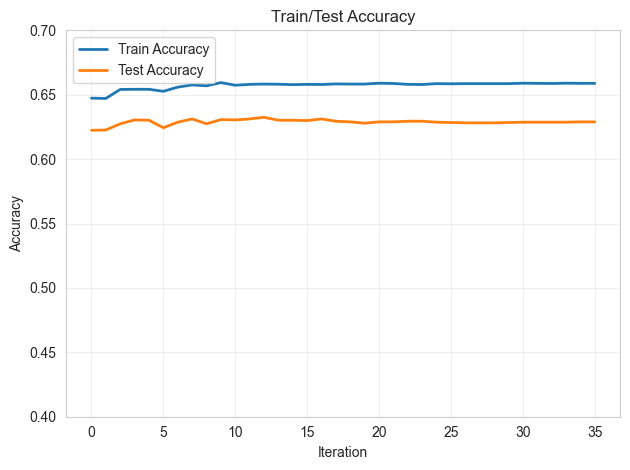

In [11]:
# --- Accuracy plot ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

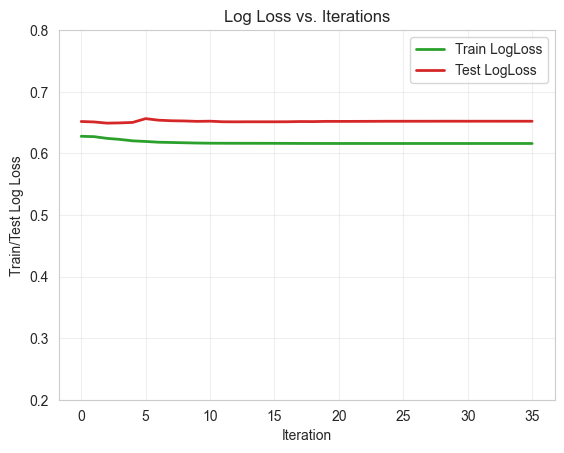

In [13]:
# Log-loss
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.2, 0.8)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 1.7 Optimization

### Bayesian Search

In [10]:
space  = [
    Real(1e-9, 1e1,   "log-uniform", name="lambda_s"),
    Real(1e-9, 1e1,   "log-uniform", name="lambda_b"),
    Real(1e-9, 1e1, "log-uniform", name="lambda_g"),
]

all_results = []

@use_named_args(space)
def objective(lambda_s, lambda_b,lambda_g):
    print(f"Trying λs={lambda_s:.4e}, λb={lambda_b:.4e}, λg={lambda_g:.4e}")


    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        lambda_g=lambda_g,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )

    result = model.fit(
        df=df,
        split_col="split",
        split_value="train",
        test_frame=test,
        max_iter=800,
        verbose=1,
    )

    acc, logloss = model.evaluate(test)

    print(f"Accuracy: {acc:.6f}")
    print(f"Logloss: {logloss:.6f}")

    # record each step for analysis later
    all_results.append({
        "lambda_s": lambda_s,
        "lambda_b": lambda_b,
        "lambda_g": lambda_g,
        "accuracy": acc,
        "logloss": logloss,
    })

    return -acc

In [11]:
result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=200,
    n_initial_points=10,  # random explorations before GP fit
    random_state=42,
    acq_func="EI"         # Expected Improvement
)

Trying λs=9.2349e-02, λb=6.8289e-08, λg=6.2648e-02
Running 5 MM iterations for initial s update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\3614919032.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6472 ll=0.6271 | Test acc=0.6227 ll=0.6509
[0002] Train acc=0.6542 ll=0.6243 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6543 ll=0.6226 | Test acc=0.6305 ll=0.6494
[0004] Train acc=0.6543 ll=0.6203 | Test acc=0.6302 ll=0.6502
[0005] Train acc=0.6525 ll=0.6192 | Test acc=0.6244 ll=0.6563
[0006] Train acc=0.6560 ll=0.6180 | Test acc=0.6287 ll=0.6538
[0007] Train acc=0.6578 ll=0.6176 | Test acc=0.6318 ll=0.6529
[0008] Train acc=0.6569 ll=0.6171 | Test acc=0.6277 ll=0.6525
[0009] Train acc=0.6592 ll=0.6167 | Test acc=0.6305 ll=0.6518
[0010] Train acc=0.6574 ll=0.6164 | Test acc=0.6302 ll=0.6521
[0011] Train acc=0.6581 ll=0.6163 | Test acc=0.6315 ll=0.6512
[0012] Train acc=0.6586 ll=0.6163 | Test acc=0.6325 ll=0.6511
[0013] Train acc=0.6581 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0014] Train acc=0.6578 ll=0.6163 | Test acc=0.6300 ll=0.6512
[0015] Train acc=0.6582 ll=0.6162 | Test acc=0.6300 ll=0.6512
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\3614919032.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6472 ll=0.6271 | Test acc=0.6227 ll=0.6509
[0002] Train acc=0.6542 ll=0.6243 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6543 ll=0.6226 | Test acc=0.6305 ll=0.6494
[0004] Train acc=0.6543 ll=0.6203 | Test acc=0.6302 ll=0.6502
[0005] Train acc=0.6527 ll=0.6192 | Test acc=0.6244 ll=0.6563
[0006] Train acc=0.6560 ll=0.6180 | Test acc=0.6287 ll=0.6538
[0007] Train acc=0.6577 ll=0.6176 | Test acc=0.6312 ll=0.6529
[0008] Train acc=0.6570 ll=0.6171 | Test acc=0.6275 ll=0.6525
[0009] Train acc=0.6595 ll=0.6167 | Test acc=0.6307 ll=0.6519
[0010] Train acc=0.6574 ll=0.6164 | Test acc=0.6305 ll=0.6522
[0011] Train acc=0.6581 ll=0.6163 | Test acc=0.6312 ll=0.6512
[0012] Train acc=0.6583 ll=0.6163 | Test acc=0.6325 ll=0.6511
[0013] Train acc=0.6582 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0014] Train acc=0.6579 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0015] Train acc=0.6581 ll=0.6162 | Test acc=0.6300 ll=0.6512
[0016] T

...

[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6472 ll=0.6271 | Test acc=0.6227 ll=0.6509
[0002] Train acc=0.6540 ll=0.6243 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6542 ll=0.6226 | Test acc=0.6305 ll=0.6494
[0004] Train acc=0.6542 ll=0.6203 | Test acc=0.6302 ll=0.6502
[0005] Train acc=0.6527 ll=0.6192 | Test acc=0.6244 ll=0.6563
[0006] Train acc=0.6560 ll=0.6180 | Test acc=0.6287 ll=0.6538
[0007] Train acc=0.6578 ll=0.6176 | Test acc=0.6310 ll=0.6529
[0008] Train acc=0.6569 ll=0.6171 | Test acc=0.6277 ll=0.6525
[0009] Train acc=0.6595 ll=0.6167 | Test acc=0.6307 ll=0.6519
[0010] Train acc=0.6574 ll=0.6164 | Test acc=0.6305 ll=0.6522
[0011] Train acc=0.6581 ll=0.6163 | Test acc=0.6312 ll=0.6512
[0012] Train acc=0.6583 ll=0.6163 | Test acc=0.6325 ll=0.6511
[0013] Train acc=0.6581 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0014] Train acc=0.6578 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0015] Train acc=0.6581 ll=0.6162 | Test acc=0.6300 ll=0.6512
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\3614919032.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6472 ll=0.6271 | Test acc=0.6227 ll=0.6509
[0002] Train acc=0.6542 ll=0.6243 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6543 ll=0.6226 | Test acc=0.6305 ll=0.6494
[0004] Train acc=0.6543 ll=0.6203 | Test acc=0.6302 ll=0.6502
[0005] Train acc=0.6527 ll=0.6192 | Test acc=0.6244 ll=0.6563
[0006] Train acc=0.6560 ll=0.6180 | Test acc=0.6287 ll=0.6538
[0007] Train acc=0.6577 ll=0.6176 | Test acc=0.6312 ll=0.6529
[0008] Train acc=0.6570 ll=0.6171 | Test acc=0.6275 ll=0.6525
[0009] Train acc=0.6595 ll=0.6167 | Test acc=0.6307 ll=0.6519
[0010] Train acc=0.6574 ll=0.6164 | Test acc=0.6305 ll=0.6522
[0011] Train acc=0.6581 ll=0.6163 | Test acc=0.6312 ll=0.6512
[0012] Train acc=0.6583 ll=0.6163 | Test acc=0.6325 ll=0.6511
[0013] Train acc=0.6582 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0014] Train acc=0.6579 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0015] Train acc=0.6581 ll=0.6162 | Test acc=0.6300 ll=0.6512
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\3614919032.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6472 ll=0.6271 | Test acc=0.6227 ll=0.6509
[0002] Train acc=0.6542 ll=0.6243 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6542 ll=0.6226 | Test acc=0.6305 ll=0.6494
[0004] Train acc=0.6542 ll=0.6203 | Test acc=0.6302 ll=0.6502
[0005] Train acc=0.6527 ll=0.6192 | Test acc=0.6244 ll=0.6563
[0006] Train acc=0.6560 ll=0.6180 | Test acc=0.6287 ll=0.6538
[0007] Train acc=0.6577 ll=0.6176 | Test acc=0.6312 ll=0.6529
[0008] Train acc=0.6570 ll=0.6171 | Test acc=0.6275 ll=0.6525
[0009] Train acc=0.6595 ll=0.6167 | Test acc=0.6307 ll=0.6519
[0010] Train acc=0.6574 ll=0.6164 | Test acc=0.6305 ll=0.6522
[0011] Train acc=0.6581 ll=0.6163 | Test acc=0.6312 ll=0.6512
[0012] Train acc=0.6583 ll=0.6163 | Test acc=0.6325 ll=0.6511
[0013] Train acc=0.6582 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0014] Train acc=0.6579 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0015] Train acc=0.6581 ll=0.6162 | Test acc=0.6300 ll=0.6512
[0016] T


Optimization completed
Best parameters: λs=7.8036e+00, λb=1.9993e-09, λg=1.4191e-05
Best accuracy: 0.610803
Best logloss: 0.658591


<Axes: >

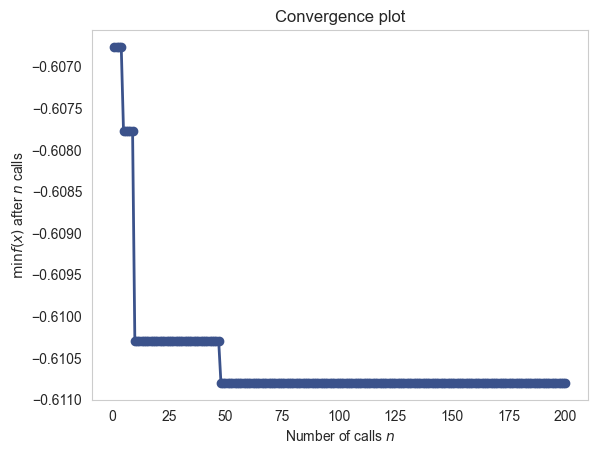

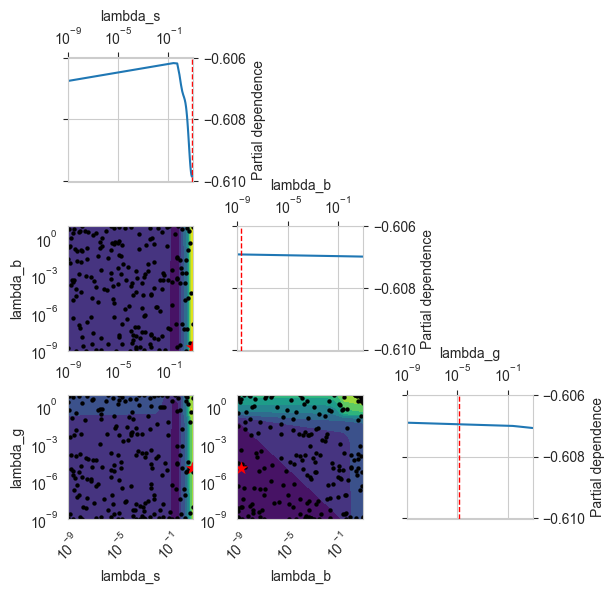

In [12]:
# best parameters found
best_lambda_s, best_lambda_b, best_lambda_g = result.x
# convert back to positive accuracy
best_acc = -result.fun
# find the matching logloss from our stored results
best_entry = min(all_results, key=lambda r: abs(r["accuracy"] - best_acc))
best_logloss = best_entry["logloss"]

print("\nOptimization completed")
print(f"Best parameters: λs={best_lambda_s:.4e}, λb={best_lambda_b:.4e}, λg={best_lambda_g:.4e}")
print(f"Best accuracy: {best_acc:.6f}")
print(f"Best logloss: {best_logloss:.6f}")

plot_convergence(result)
plot_objective(result)

In [26]:
model_l2 = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=best_lambda_s,
    lambda_b=best_lambda_b,
    lambda_g=best_lambda_g,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)

start = time.time()
fit_model_l2 = model_l2.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    verbose=1,
    test_frame=test,
)
time_l2 = time.time() - start
# Final metrics (you can also recompute)
tr_acc,tr_ll = model_l2.evaluate(train)
t_acc, t_ll = model_l2.evaluate(test)

Running 5 MM iterations for initial s update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\3614919032.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6471 ll=0.6271 | Test acc=0.6232 ll=0.6509
[0002] Train acc=0.6544 ll=0.6244 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6544 ll=0.6228 | Test acc=0.6297 ll=0.6492
[0004] Train acc=0.6554 ll=0.6205 | Test acc=0.6297 ll=0.6495
[0005] Train acc=0.6536 ll=0.6192 | Test acc=0.6254 ll=0.6543
[0006] Train acc=0.6545 ll=0.6183 | Test acc=0.6280 ll=0.6521
[0007] Train acc=0.6560 ll=0.6179 | Test acc=0.6300 ll=0.6513
[0008] Train acc=0.6574 ll=0.6174 | Test acc=0.6305 ll=0.6508
[0009] Train acc=0.6589 ll=0.6169 | Test acc=0.6295 ll=0.6501
[0010] Train acc=0.6580 ll=0.6165 | Test acc=0.6295 ll=0.6502
[0011] Train acc=0.6580 ll=0.6165 | Test acc=0.6287 ll=0.6495
[0012] Train acc=0.6570 ll=0.6165 | Test acc=0.6310 ll=0.6494
[0013] Train acc=0.6578 ll=0.6165 | Test acc=0.6300 ll=0.6495
[0014] Train acc=0.6577 ll=0.6164 | Test acc=0.6300 ll=0.6495
[0015] Train acc=0.6573 ll=0.6164 | Test acc=0.6302 ll=0.6495
[0016] T

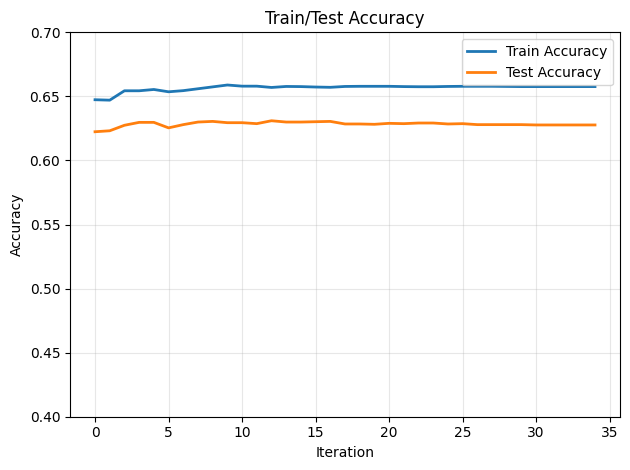

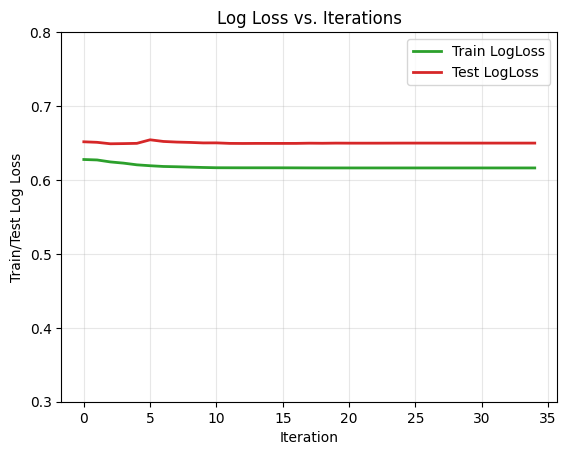

In [284]:
# --- Convert to numpy arrays for plotting ---
hist_baye = result["history"]

# convert arrays safely
iters     = np.array(hist_baye["iter"], dtype=float)
train_acc = np.array(hist_baye["train_acc"], dtype=float)
test_acc  = np.array(hist_baye["test_acc"], dtype=float)
train_ll  = np.array(hist_baye["train_logloss"], dtype=float)
test_ll   = np.array(hist_baye["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.3, 0.8)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [30]:
def calibration_curve_with_ci(y_true, p_pred, n_bins=10, strategy="uniform", title="Calibration Curve (Reliability Diagram)"):
    """
    Plots calibration curve with 95% binomial CIs for each bin.
    y_true: array-like of shape (n_samples,), values in {0,1}
    p_pred: array-like of predicted probabilities in [0,1]
    n_bins: number of bins
    strategy: "uniform" (equal-width in probability) or "quantile" (equal-count)
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    df = pd.DataFrame({"y": y_true, "p": p_pred})

    if strategy == "quantile":
        # Bin by quantiles of predicted probability (equal count)
        # Ensure unique bin edges
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(df["p"], quantiles))
        # If many ties shrink number of bins
        if len(edges) - 1 < n_bins:
            n_bins = len(edges) - 1
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True, duplicates="drop")
    elif strategy == "uniform":
        edges = np.linspace(0.0, 1.0, n_bins + 1)
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True)
    else:
        raise ValueError("strategy must be 'uniform' or 'quantile'")

    grp = df.groupby("bin", observed=False)
    n = grp.size().values
    if len(n) == 0:
        raise ValueError("No bins formed. Check inputs.")

    p_mean = grp["p"].mean().values
    y_mean = grp["y"].mean().values  # observed frequency
    # 95% binomial proportion CI using Wilson or Beta posterior (Jeffreys)
    # Here: Jeffreys interval via Beta(0.5,0.5) posterior for robustness in small bins.
    k = (grp["y"].sum()).values
    lower = beta_dist.ppf(0.025, k + 0.5, n - k + 0.5)
    upper = beta_dist.ppf(0.975, k + 0.5, n - k + 0.5)

    # Plot
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
    ax.errorbar(p_mean, y_mean, yerr=[y_mean - lower, upper - y_mean],
                fmt="o", color="#1f77b4", ecolor="#1f77b4", elinewidth=1, capsize=3, label="Bins")
    # Bin sizes as marker size
    ms = 20 * (n / n.max())
    ax.scatter(p_mean, y_mean, s=ms, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(title + f"\n(n={len(y_true)}, bins={n_bins}, strategy={strategy})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

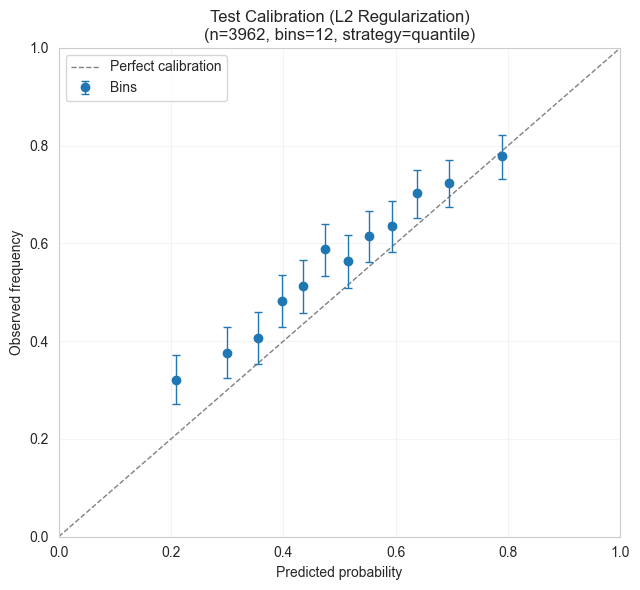

In [31]:
y_true_test = test['home_win'].astype(int).values
p_pred_test = model_l2.predict_proba(test)
calibration_curve_with_ci(y_true_test, p_pred_test, n_bins=12, strategy="quantile", title="Test Calibration (L2 Regularization)")

In [32]:
def normal_probability_plot_with_band(y_true, p_pred, n_sim=500, title="Normal Probability Plot of Standardized Residuals"):
    """
    Creates a Q–Q plot for standardized probability residuals r = (y - p) / sqrt(p(1-p)),
    with a 95% simulation band that accounts for heteroskedastic Bernoulli noise.
    The band is generated by parametric bootstrap under the fitted probabilities.
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    # Standardized residuals (Pearson residuals for Bernoulli)
    r = (y_true - p_pred) / np.sqrt(p_pred * (1 - p_pred))

    # Sort residuals and their theoretical normal quantiles
    r_sorted = np.sort(r)
    n = len(r_sorted)
    probs = (np.arange(1, n + 1) - 0.5) / n
    z_theory = norm.ppf(probs)

    # Simulation band: simulate y* ~ Bernoulli(p_pred), compute residuals, take order stats
    rng = np.random.default_rng(12345)
    sim_order_stats = np.empty((n_sim, n), dtype=float)
    for s in range(n_sim):
        y_sim = rng.binomial(1, p_pred)
        r_sim = (y_sim - p_pred) / np.sqrt(p_pred * (1 - p_pred))
        sim_order_stats[s, :] = np.sort(r_sim)

    lower = np.quantile(sim_order_stats, 0.025, axis=0)
    upper = np.quantile(sim_order_stats, 0.975, axis=0)

    # Plot
    fig, ax = plt.subplots(figsize=(6.8, 6.0))
    ax.fill_between(z_theory, lower, upper, color="#d3e5ff", alpha=0.8, label="95% simulation band")
    ax.plot(z_theory, r_sorted, "o", ms=3, color="#1f77b4", label="Empirical residuals")
    ax.plot([z_theory.min(), z_theory.max()], [z_theory.min(), z_theory.max()],
            "--", color="gray", lw=1, label="y=x")

    ax.set_xlabel("Theoretical quantiles N(0,1)")
    ax.set_ylabel("Ordered residuals")
    ax.set_title(title + f"\n(n={n})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

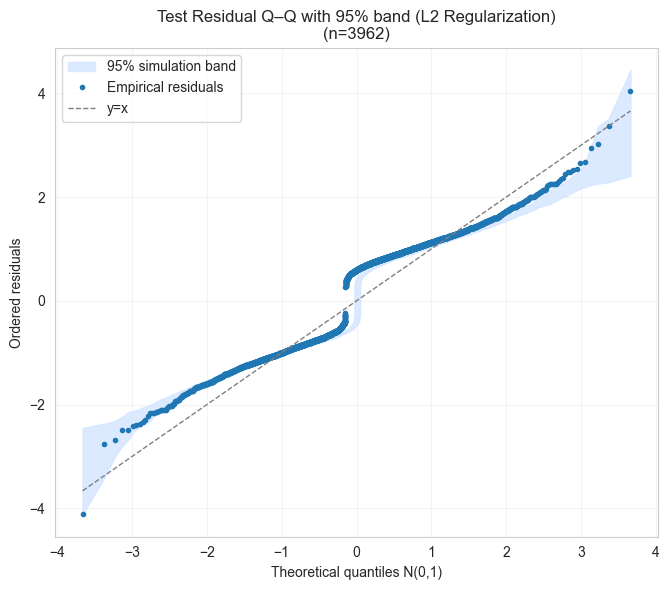

In [35]:
normal_probability_plot_with_band(y_true_test, p_pred_test, n_sim=800, title="Test Residual Q–Q with 95% band (L2 Regularization)")

### Finalized Model

In [285]:
final_df = df[df["split"] == "valid"]
final_df.drop(["split"], axis=1, inplace=True)
final_df.head()

C:\Users\hosiu\AppData\Local\Temp\ipykernel_34648\4279595533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.drop(["split"], axis=1, inplace=True)


,season,GAME_ID,home_abbr,away_abbr,home_win,home_b2b,away_b2b,home_rest_days,away_rest_days,rest_diff,diff_recent_margin,diff_recent_win_pct,diff_pts_pg_to_date,split_win_pct_delta,season_start_year,Game_Type
12836,2024-25,42400407,OKC,IND,1,0,0,2,2,0,1.6,0.1,9.266330,0.312013,2024,playoff
12837,2024-25,42400406,IND,OKC,1,0,0,2,2,0,-7.1,-0.2,-9.665781,-0.043179,2024,playoff
12838,2024-25,42400405,OKC,IND,1,0,0,2,2,0,7.8,0.1,9.549266,0.299327,2024,playoff
12839,2024-25,42400404,IND,OKC,0,0,0,1,1,0,-4.3,0.1,-9.506008,-0.024510,2024,playoff
12840,2024-25,42400403,IND,OKC,1,0,0,2,2,0,-4.8,0.0,-9.766691,-0.044706,2024,playoff


In [295]:
final_model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=best_lambda_s,
    lambda_b=best_lambda_b,
    lambda_g=best_lambda_g,
    threshold=0.65,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context,
    sd_context=sd_context,
)

# Fit using all combined training data
final_model.fit(
    df=train,
    max_iter=1200,
    verbose=1,
)

Running 5 MM iterations for initial s update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_34648\3614919032.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.5615 ll=0.6277 | Test acc=nan ll=nan
[0001] Train acc=0.5621 ll=0.6271 | Test acc=nan ll=nan
[0002] Train acc=0.5654 ll=0.6244 | Test acc=nan ll=nan
[0003] Train acc=0.5728 ll=0.6228 | Test acc=nan ll=nan
[0004] Train acc=0.5863 ll=0.6205 | Test acc=nan ll=nan
[0005] Train acc=0.5987 ll=0.6192 | Test acc=nan ll=nan
[0006] Train acc=0.5991 ll=0.6183 | Test acc=nan ll=nan
[0007] Train acc=0.6013 ll=0.6179 | Test acc=nan ll=nan
[0008] Train acc=0.6031 ll=0.6174 | Test acc=nan ll=nan
[0009] Train acc=0.6081 ll=0.6169 | Test acc=nan ll=nan
[0010] Train acc=0.6126 ll=0.6165 | Test acc=nan ll=nan
[0011] Train acc=0.6138 ll=0.6165 | Test acc=nan ll=nan
[0012] Train acc=0.6114 ll=0.6165 | Test acc=nan ll=nan
[0013] Train acc=0.6109 ll=0.6165 | Test acc=nan ll=nan
[0014] Train acc=0.6105 ll=0.6164 | Test acc=nan ll=nan
[0015] Train acc=0.6102 ll=0.6164 | Test acc=nan ll=nan
[0016] Train acc=0.6110 ll=0.6164 | Test acc=nan ll=nan
[0017] Train acc=0.6099 ll=0.6163 | Test acc=nan

{'opt_result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 5485.423044437798
         x: [-2.427e-03 -1.321e-01 ...  6.120e-02  1.855e-01]
       nit: 35
       jac: [ 2.152e-02 -2.135e-03 ... -2.547e-04 -3.772e-03]
      nfev: 39
      njev: 39
  hess_inv: <69x69 LbfgsInvHessProduct with dtype=float64>,
 'history': {'iter': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34],
  'train_acc': [np.float64(0.5615280594996619),
   np.float64(0.5620915032679739),
   np.float64(0.565359477124183),
   np.float64(0.5727969348659003),
   np.float64(0.5863195853053865),
   np.float64(0.5987153482082488),
   np.float64(0.599053414469236),
   np.float64(0.6013071895424836),
   np.float64(0.6031102096010819),
   np.float64(0.6080685147622267),
   np.float64(0

### Save Model

In [296]:
save_model(
    final_model,
    path_npz="models/btwithcovariates_new.npz",
    path_json="models/btwithcovariates_new.json",
)

Model parameters saved to models/btwithcovariates_new.json
Model saved successfully to models/btwithcovariates_new.npz


### 1.B Validation

Model (BTWithCovariates) loaded successfully from models/btwithcovariates_new.npz
Teams: 30 | Features: 4 | Contexts: 5


C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\2991589470.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df["HCA_context"] = Z_valid @ model.gamma
C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\2991589470.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df["HCA_total"] = home_alpha + valid_df["HCA_context"]
C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\2991589470.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

,home_abbr,away_abbr,HCA_context,HCA_total,theta_game,pred_prob_home_win,pred_label,home_win
12836,OKC,IND,-0.021379,0.078621,1.081795,0.710097,1,1
12837,IND,OKC,-0.021379,0.078621,1.081795,0.297629,0,1
12838,OKC,IND,-0.021379,0.078621,1.081795,0.734747,1,1
12839,IND,OKC,-0.060768,0.039232,1.040012,0.311411,0,0
12840,IND,OKC,-0.021379,0.078621,1.081795,0.310688,0,1
...,...,...,...,...,...,...,...,...
14146,MIA,ORL,0.057401,0.157401,1.170464,0.708785,1,0
14147,TOR,CLE,0.057401,0.157401,1.170464,0.772425,1,0
14148,POR,GSW,0.057401,0.157401,1.170464,0.424218,0,0
14149,BOS,NYK,0.074167,0.174167,1.190254,0.805434,1,1


Evaluation Metrics on Validation Data
Accuracy : 0.5932
Log Loss : 0.6227
Precision: 0.7637
Recall   : 0.3691
F1 Score : 0.4977


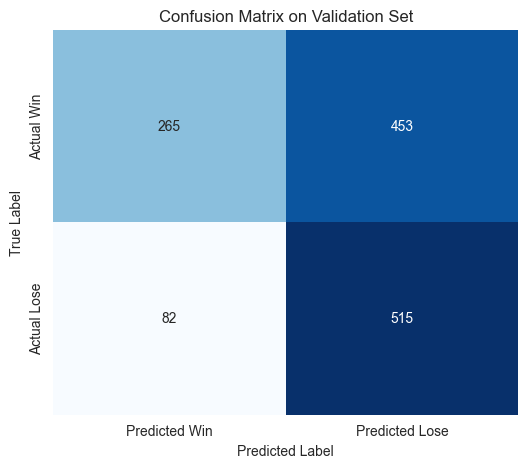

In [57]:
model = load_model("models/btwithcovariates_new.npz")
valid_df = df[df["split"] == "valid"]

# Standardize context columns
Z_valid = np.zeros((len(valid_df), len(model.context_cols)))
for j, col in enumerate(model.context_cols):
    Z_valid[:, j] = (valid_df[col] - model.mu_context[j]) / model.sd_context[j]
# --- 1. Compute contextual HCA contribution ---
valid_df["HCA_context"] = Z_valid @ model.gamma

# --- 2. Select the home team's alpha_hca for each game ---
home_alpha = np.array([model.alpha_hca[model.team_to_idx[t]] for t in valid_df["home_abbr"]])

# --- 3. HCA total = home team alpha + contextual HCA ---
valid_df["HCA_total"] = home_alpha + valid_df["HCA_context"]

# --- 4. Convert to multiplicative theta (exp of additive log advantage) ---
valid_df["theta_game"] = np.exp(valid_df["HCA_total"])

# --- 5. Compute predicted win probability ---
valid_df["pred_prob_home_win"] = model.predict_proba(valid_df)
valid_df["pred_label"] = (valid_df["pred_prob_home_win"] >= model.threshold).astype(int)

# --- 6. Filter and select columns ---
valid_df = valid_df[(valid_df["home_abbr"] != "NONE") & (valid_df["away_abbr"].notna())]
valid_df = valid_df[[
    "home_abbr", "away_abbr",
    "HCA_context", "HCA_total", "theta_game",
    "pred_prob_home_win", "pred_label", "home_win"
]]
display(valid_df)

valid_df.to_csv("./results/valid_result.csv", index=False)

# --- Extract prediction and true labels ---
y_true = valid_df["home_win"]
y_pred = valid_df["pred_label"]

# --- Compute evaluation metrics ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
logloss = log_loss(y_true, valid_df["pred_prob_home_win"])

# --- Print summary ---
print("Evaluation Metrics on Validation Data")
print(f"Accuracy : {acc:.4f}")
print(f"Log Loss : {logloss:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
cm_display = ConfusionMatrixDisplay(cm, display_labels=["Home Win (1)", "Home Lose (0)"])

# --- Visualize nicely ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Win", "Predicted Lose"],
            yticklabels=["Actual Win", "Actual Lose"])
plt.title("Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

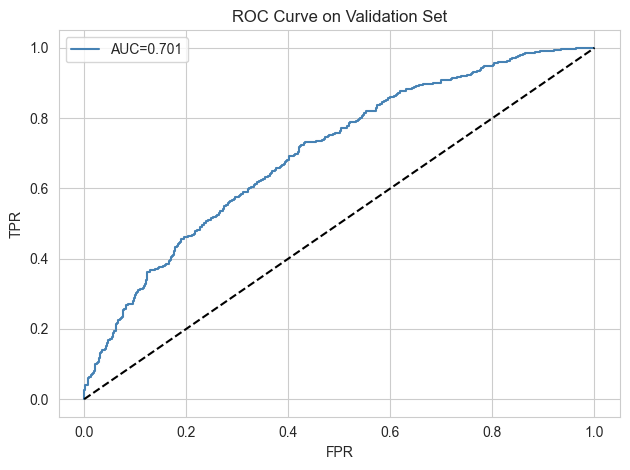

In [58]:
auc = roc_auc_score(y_true, valid_df["pred_prob_home_win"])
fpr, tpr, _ = roc_curve(y_true, valid_df["pred_prob_home_win"])
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}", color='steelblue')
plt.plot([0,1],[0,1],'k--')
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve on Validation Set")
plt.tight_layout(); plt.show()

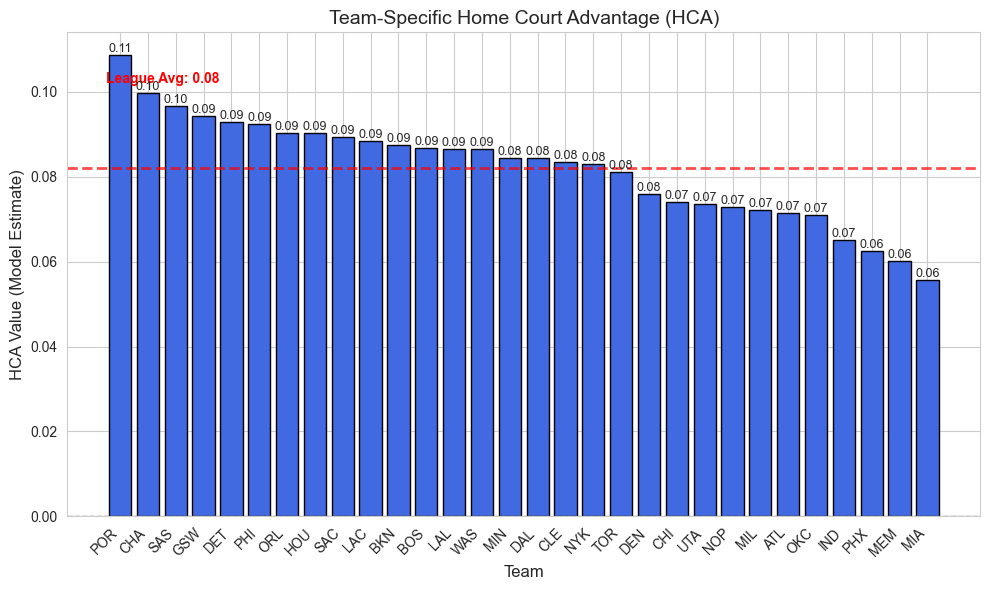

In [46]:
valid_results_l2 = pd.read_csv("./results/valid_result.csv")

team_total_hca = (
    valid_results_l2.groupby("home_abbr")["HCA_total"]
    .mean()
    .sort_values(ascending=False)
)

hca_df = team_total_hca.reset_index().rename(
    columns={"home_abbr": "Team", "HCA_total": "HCA"}
)

# Compute league average HCA
league_avg_hca = hca_df["HCA"].mean()

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(hca_df["Team"], hca_df["HCA"], color="royalblue", edgecolor="black")

# Add horizontal lines
plt.axhline(0, color="gray", linewidth=1, linestyle="--")  # baseline zero
plt.axhline(y=league_avg_hca, color="red", linestyle="--", linewidth=2, alpha=0.7)  # league avg

# Annotate league average text
plt.text(-0.5, league_avg_hca + 0.02 if league_avg_hca >= 0 else league_avg_hca - 0.02,
         f"League Avg: {league_avg_hca:.2f}", color='red', fontsize=10, weight='bold')

# Labels and formatting
plt.title("Team-Specific Home Court Advantage (HCA)", fontsize=14)
plt.ylabel("HCA Value (Model Estimate)", fontsize=12)
plt.xlabel("Team", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Annotate each bar numerically
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.2f}", ha="center",
             va="bottom" if yval >= 0 else "top",
             fontsize=9)

plt.tight_layout()
plt.show()

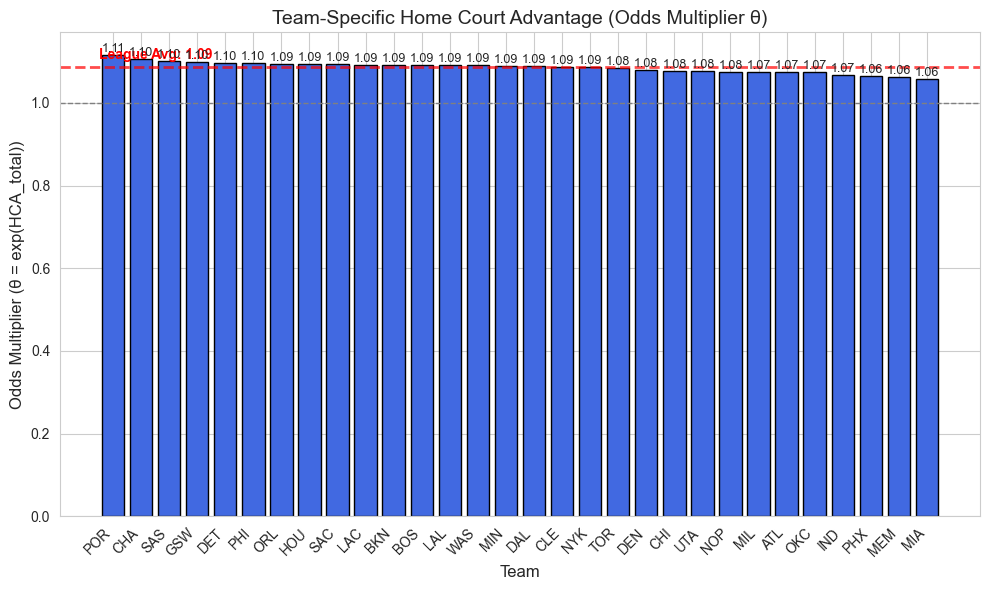

In [47]:
hca_df["Theta"] = np.exp(hca_df["HCA"])

plt.figure(figsize=(10, 6))
bars = plt.bar(hca_df["Team"], hca_df["Theta"], color="royalblue", edgecolor="black")

league_avg_theta = hca_df["Theta"].mean()

# Add horizontal lines
plt.axhline(1, color="gray", linewidth=1, linestyle="--")  # neutral odds multiplier = 1
plt.axhline(y=league_avg_theta, color="red", linestyle="--", linewidth=2, alpha=0.7)

# Annotate
plt.text(-0.5,
         league_avg_theta + 0.02 if league_avg_theta >= 1 else league_avg_theta - 0.02,
         f"League Avg: {league_avg_theta:.2f}",
         color='red', fontsize=10, weight='bold')

plt.title("Team-Specific Home Court Advantage (Odds Multiplier θ)", fontsize=14)
plt.ylabel("Odds Multiplier (θ = exp(HCA_total))", fontsize=12)
plt.xlabel("Team", fontsize=12)

plt.xticks(rotation=45, ha="right")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.2f}", ha="center",
             va="bottom" if yval >= 1 else "top",
             fontsize=9)
plt.tight_layout()
plt.show()

In [190]:
pair_summary = (
    valid_df
    .groupby(["home_abbr", "away_abbr"], as_index=False)
    .agg(
        avg_HCA=("HCA_total", "mean"),
        avg_pred_prob_home_win=("pred_prob_home_win", "mean"),
        total_home_win=("home_win", "sum"),
        total_predicted_win=("pred_label", "sum"),
        total_games=("pred_label", "count")
    )
)

# Complementary counts
pair_summary["total_predicted_lose"] = (
    pair_summary["total_games"] - pair_summary["total_predicted_win"]
)

pair_summary["pred_label"] = (
    pair_summary["avg_pred_prob_home_win"] > 0.5
).astype(int)

pair_summary.to_csv("results/1vs29_summary.csv",index=False)

# Evaluate Model Performance per Game Type

# BT Covariates with Elasticnet

In [14]:
class BTCVwithElastic:
    def __init__(
        self,
        teams, team_to_idx,
        s, beta,
        feature_cols, mu, sd,
        context_cols=None, gamma=None,
        mu_context=None, sd_context=None,
        lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3, lambda_a=None,
        l1_ratio=None,
        threshold=0.5,alpha_hca=None
    ):
        # --- core team parameters ---
        self.teams = list(teams)
        self.team_to_idx = {t: i for i, t in enumerate(self.teams)}
        self.s = np.array(s, dtype=float)
        self.s -= self.s.mean()  # mean‑centering for identifiability
        self.alpha_hca = np.full(len(self.teams), 0.1)

        # --- feature-related parameters X@beta ---
        self.feature_cols = list(feature_cols)
        self.beta = np.array(beta, dtype=float)
        self.mu = np.array(mu, dtype=float)
        self.sd = np.array(sd, dtype=float)
        self.sd[self.sd == 0] = 1.0

        # --- contextual HCA parameters Z@gamma ---
        self.context_cols = list(context_cols) if context_cols else []
        self.gamma = (
            np.random.normal(0, 0.01, len(self.context_cols))
            if gamma is None
            else np.array(gamma, dtype=float)
        )
        self.mu_context = (
            np.zeros(len(self.context_cols))
            if mu_context is None
            else np.array(mu_context, dtype=float)
        )
        self.sd_context = (
            np.ones(len(self.context_cols))
            if sd_context is None
            else np.array(sd_context, dtype=float)
        )
        self.sd_context[self.sd_context == 0] = 1.0

        # learning configuration
        self.lambda_s, self.lambda_b, self.lambda_g = lambda_s, lambda_b, lambda_g
        self.lambda_a = lambda_a if lambda_a is not None else lambda_s * 0.2
        self.l1_ratio = l1_ratio
        self.threshold = threshold

    # ---------------- Properties ----------------
    @property
    def m(self): return len(self.teams)
    @property
    def p(self): return len(self.feature_cols)
    @property
    def q(self): return len(self.context_cols)

    # ---------------- Utilities ----------------
    def _ensure_teams(self, df: pd.DataFrame):
        """Ensure unseen teams get added dynamically."""
        unseen = [
            t for t in pd.unique(df[['home_abbr', 'away_abbr']].values.ravel())
            if t not in self.team_to_idx
        ]
        if not unseen:
            return
        start = len(self.teams)
        for k, t in enumerate(unseen):
            self.team_to_idx[t] = start + k
        self.teams.extend(unseen)

        # Expand both s and alpha_hca for new teams
        self.s = np.concatenate([self.s, np.zeros(len(unseen))])
        new_alpha = np.full(len(unseen), 0.1)  # same scale as existing α initialization
        self.alpha_hca = np.concatenate([self.alpha_hca, new_alpha])

        # Mean-center strengths (s)
        self.s -= self.s.mean()

    def _standardize(self, arr, mu, sd):
        return (arr - mu) / (sd if sd != 0 else 1.0)

    def _standardize_features(self, frame):
        if self.p == 0:
            return np.zeros((len(frame), 0))
        X = np.zeros((len(frame), self.p))
        for j, col in enumerate(self.feature_cols):
            X[:, j] = self._standardize(frame[col].astype(float).values, self.mu[j], self.sd[j])
        return X

    def _standardize_context(self, frame):
        if self.q == 0:
            return np.zeros((len(frame), 0))
        Z = np.zeros((len(frame), self.q))
        for j, col in enumerate(self.context_cols):
            Z[:, j] = self._standardize(
                frame[col].astype(float).values, self.mu_context[j], self.sd_context[j]
            )
        return Z

    # ---------------- Prediction ----------------
    def predict_proba(self, frame: pd.DataFrame) -> np.ndarray:
        sh = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["home_abbr"]])
        sa = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["away_abbr"]])

        h_idx = np.array([self.team_to_idx[t] for t in frame["home_abbr"]])
        z = (sh - sa) + self.alpha_hca[h_idx]

        if self.q:
            Z = self._standardize_context(frame)
            z += Z @ self.gamma
        if self.p:
            X = self._standardize_features(frame)
            z += X @ self.beta

        # apply sigmoid
        p = 1.0 / (1.0 + np.exp(-z))
        return p

    def predict_class(self, frame: pd.DataFrame, threshold=None) -> np.ndarray:
        threshold = self.threshold if threshold is None else threshold
        return (self.predict_proba(frame) >= threshold).astype(int)

    # ---------------- Evaluation ----------------
    def evaluate(self, frame: pd.DataFrame, threshold=None):
        threshold = self.threshold if threshold is None else threshold
        p = self.predict_proba(frame)
        y_true = frame["home_win"].astype(int).values
        yhat = (p >= threshold).astype(int)
        acc = (yhat == y_true).mean()
        logloss = -(y_true * np.log(p + 1e-12)
                    + (1 - y_true) * np.log(1 - p + 1e-12)).mean()
        return acc, logloss


    def _mm_update_s(self, home_idx, away_idx, y, X, Z, beta, gamma, mm_iter=5):
            """Perform MM updates for team strengths s while holding beta,gamma fixed."""
            m = self.m
            s = self.s.copy()
            for _ in range(mm_iter):
                exp_s = np.exp(s)
                num = np.zeros(m)
                denom = np.zeros(m)

                for i in range(len(y)):
                    h, a = home_idx[i], away_idx[i]
                    eta = self.alpha_hca[h]
                    if X.shape[1]:
                        eta += X[i] @ beta
                    if Z.shape[1]:
                        eta += Z[i] @ gamma
                    p_hat = 1.0 / (1.0 + np.exp(-(s[h] - s[a] + eta)))

                    # Accumulate numerators/denominators
                    num[h] += y[i]
                    num[a] += 1.0 - y[i]
                    denom[h] += p_hat
                    denom[a] += 1.0 - p_hat

                s = np.log((num + 1e-12) / (denom + 1e-12))
                s -= s.mean()   # identifiability
            return s

    def fit(self, df, split_col=None, split_value=None, test_frame=None, max_iter=1000,
            mm_iter=5, verbose=1):

        data = df if split_col is None else df[df[split_col] == split_value]
        if len(data) == 0:
            raise ValueError("Empty training data.")

        self._ensure_teams(data)

        home_idx = np.array([self.team_to_idx[t] for t in data["home_abbr"]], int)
        away_idx = np.array([self.team_to_idx[t] for t in data["away_abbr"]], int)
        y = data["home_win"].astype(float).values
        X = self._standardize_features(data)
        Z = self._standardize_context(data)
        m, p, q = self.m, self.p, self.q

        # ---------- Step 1: MM update for s (given current beta,gamma) ----------
        if verbose:
            print(f"Running {mm_iter} MM iterations for initial team strength update...")
        self.s = self._mm_update_s(home_idx, away_idx, y, X, Z,
                                   self.beta.copy(), self.gamma.copy(),
                                   mm_iter=mm_iter)



        # Define joint objective for L‑BFGS ----------
        def objective(x):
            ratio = 0.0 if self.l1_ratio is None else self.l1_ratio

            # Define Elastic Net Penalty function
            def elasticNet_penalty(w,lam):
                l1 = np.sum(np.abs(w))
                l2 = np.sum(w**2)
                return lam * (ratio * l1 + (1 - ratio) * 0.5 * l2)

            def elastic_net_grad(w, lam):
                return lam * (
                    ratio * np.sign(w) + (1 - ratio) * w
                )

            s = x[:m]
            b = x[m:m+p]
            g = x[m+p:m+p+q]
            a = x[m+p+q:m+p+q+m]
            z = (s[home_idx] - s[away_idx]) + a[home_idx]
            if p: z += X @ b
            if q: z += Z @ g
            p_hat = 1 / (1 + np.exp(-z))
            nll = -np.sum(y * np.log(p_hat + 1e-12) +
                          (1 - y) * np.log(1 - p_hat + 1e-12))
            reg = (elasticNet_penalty(s,self.lambda_s)+elasticNet_penalty(b,self.lambda_b)
                   +elasticNet_penalty(g,self.lambda_g)+elasticNet_penalty(a, self.lambda_a))
            loss = nll + reg

            err = y - p_hat
            # --- base gradients (from likelihood) ---
            grad_s = np.zeros_like(s)
            np.add.at(grad_s, home_idx, -err)
            np.add.at(grad_s, away_idx, err)

            grad_b = -(X.T @ err) if p else np.zeros(0)
            grad_g = -(Z.T @ err) if q else np.zeros(0)
            grad_a = np.zeros_like(a)
            np.add.at(grad_a, home_idx, -err)
            grad_a += elastic_net_grad(a, self.lambda_a)

            # --- add elastic net gradients ---
            grad_s += elastic_net_grad(s, self.lambda_s)
            if p:
                grad_b += elastic_net_grad(b, self.lambda_b)
            if q:
                grad_g += elastic_net_grad(g, self.lambda_g)

            grad = np.concatenate([grad_s, grad_b, grad_g, grad_a])
            return loss, grad

        # History tracking
        history = {"iter": [], "train_acc": [], "train_logloss": [],
                   "test_acc": [],  "test_logloss": []}

        iter_counter = {"i": 0}

        def callback(xk):
            i = iter_counter["i"]
            iter_counter["i"] += 1

            self.s = xk[:m] - np.mean(xk[:m])
            self.beta = xk[m:m+p]
            self.gamma = xk[m+p:m+p+q]
            self.alpha_hca = xk[m+p+q:]

            tr_acc, tr_ll = self.evaluate(data)
            te_acc, te_ll = (np.nan, np.nan)
            if test_frame is not None:
                te_acc, te_ll = self.evaluate(test_frame)

            history["iter"].append(i)
            history["train_acc"].append(tr_acc)
            history["train_logloss"].append(tr_ll)
            history["test_acc"].append(te_acc)
            history["test_logloss"].append(te_ll)

            if verbose and i % verbose == 0:
                print(f"[{i:04d}] Train acc={tr_acc:.4f} ll={tr_ll:.4f} | "
                      f"Test acc={te_acc:.4f} ll={te_ll:.4f}")

        # ---------- L‑BFGS Optimization ----------
        x0 = np.concatenate([self.s, self.beta, self.gamma, self.alpha_hca])
        res = minimize(
            objective, x0, jac=True, method="L-BFGS-B",
            callback=callback,
            options={"disp": True, "maxiter": max_iter}
        )

        # ---------- Post‑process ----------
        opt = res.x
        self.s = opt[:m]
        self.beta = opt[m:m+p]
        self.gamma = opt[m+p:m+p+q]
        self.alpha_hca = opt[m+p+q:]
        self.s -= self.s.mean()
        self.alpha_hca -= np.mean(self.alpha_hca)

        tr_acc, tr_ll = self.evaluate(data)
        te_acc, te_ll = (np.nan, np.nan)
        if test_frame is not None:
            te_acc, te_ll = self.evaluate(test_frame)

        history["iter"].append(len(history["iter"]))
        history["train_acc"].append(tr_acc)
        history["train_logloss"].append(tr_ll)
        history["test_acc"].append(te_acc)
        history["test_logloss"].append(te_ll)

        theta = np.exp(self.alpha_hca)
        print(f"HCA θ: mean={theta.mean():.4f}, std={theta.std():.4f}, min={theta.min():.4f}, max={theta.max():.4f}")
        if verbose:
            print(f"Final: Train acc={tr_acc:.6f}, logloss={tr_ll:.6f}")

        return {"opt_result": res, "history": history}

In [15]:
en_model = BTCVwithElastic(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init.copy(),
    beta=beta_init.copy(),
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    context_cols=context_cols,
    gamma=gamma_init.copy(),
    mu_context=mu_context,
    sd_context=sd_context,
    alpha_hca=np.zeros(len(teams))
)
result_baseline = en_model.fit(
    df,
    split_col="split",
    split_value="train",
    test_frame=test,
    max_iter=1000,
    verbose=1
)

tr_acc, tr_ll = en_model.evaluate(train)
te_acc, te_ll = en_model.evaluate(test)

print(f"Baseline (no tuning)")
print(f"Train  -> acc={tr_acc:.4f}, logloss={tr_ll:.4f}")
print(f"Test   -> acc={te_acc:.4f}, logloss={te_ll:.4f}")

Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1671089307.py:274: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6474 ll=0.6277 | Test acc=0.6224 ll=0.6516
[0001] Train acc=0.6472 ll=0.6271 | Test acc=0.6227 ll=0.6509
[0002] Train acc=0.6542 ll=0.6243 | Test acc=0.6275 ll=0.6490
[0003] Train acc=0.6543 ll=0.6226 | Test acc=0.6305 ll=0.6494
[0004] Train acc=0.6543 ll=0.6203 | Test acc=0.6302 ll=0.6502
[0005] Train acc=0.6527 ll=0.6192 | Test acc=0.6244 ll=0.6563
[0006] Train acc=0.6560 ll=0.6180 | Test acc=0.6287 ll=0.6538
[0007] Train acc=0.6577 ll=0.6176 | Test acc=0.6312 ll=0.6529
[0008] Train acc=0.6570 ll=0.6171 | Test acc=0.6275 ll=0.6525
[0009] Train acc=0.6595 ll=0.6167 | Test acc=0.6307 ll=0.6519
[0010] Train acc=0.6574 ll=0.6164 | Test acc=0.6305 ll=0.6522
[0011] Train acc=0.6581 ll=0.6164 | Test acc=0.6312 ll=0.6512
[0012] Train acc=0.6583 ll=0.6163 | Test acc=0.6325 ll=0.6511
[0013] Train acc=0.6582 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0014] Train acc=0.6579 ll=0.6163 | Test acc=0.6302 ll=0.6512
[0015] Train acc=0.6581 ll=0.6162 | Test acc=0.6300 ll=0.6512
[0016] T

# Bayesian Search

In [16]:
space = [
    Real(1e-5, 1e-1, "log-uniform", name="lambda_s"),
    Real(1e-5, 1e-1, "log-uniform", name="lambda_b"),
    Real(1e-5, 1e-1, "log-uniform", name="lambda_g"),
    Real(1e-5,1e-2,"log-uniform",name="lambda_a"),
    Real(0.05, 0.7, name="l1_ratio"),
    Real(0.3, 0.7, name="threshold")
]

all_results = []

@use_named_args(space)
def objective(lambda_s, lambda_b, lambda_g,lambda_a, l1_ratio,threshold):
    print(f"Trying λs={lambda_s:.4e}, λb={lambda_b:.4e}, λg={lambda_g:.4e},λa={lambda_a:.4e}, l1_ratio={l1_ratio:.2f}, Threshold={threshold:.2f}")

    model = BTCVwithElastic(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init.copy(),
        beta=beta_init.copy(),
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        context_cols=context_cols,
        gamma=gamma_init.copy(),
        mu_context=mu_context,
        sd_context=sd_context,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        lambda_g=lambda_g,
        lambda_a=lambda_a,
        l1_ratio=l1_ratio,
        threshold=threshold,
    )

    try:
        result = model.fit(
            df=df,
            split_col="split",
            split_value="train",
            test_frame=test,
            max_iter=1000,
            verbose=1
        )

        acc, logloss = model.evaluate(test)
    except Exception as e:
        print(f"Trial failed: {e}")
        acc, logloss = 0.0, np.inf

    print(f"Accuracy: {acc:.6f}")
    print(f"Logloss: {logloss:.6f}")

    all_results.append({
        "lambda_s": lambda_s,
        "lambda_b": lambda_b,
        "lambda_g": lambda_g,
        "lambda_a": lambda_a,
        "l1_ratio": l1_ratio,
        "accuracy": acc,
        "logloss": logloss,
    })

    # negative accuracy → we want to maximize acc
    return -acc

search_result = gp_minimize(
    objective,
    dimensions=space,
    n_calls=200,          # number of parameter trials
    n_random_starts=5,   # initial random points
    random_state=42,
    verbose=True,
)

best_idx = np.argmin(search_result.func_vals)
best_params = {
    "lambda_s": search_result.x_iters[best_idx][0],
    "lambda_b": search_result.x_iters[best_idx][1],
    "lambda_g": search_result.x_iters[best_idx][2],
    "lambda_a": search_result.x_iters[best_idx][3],
    "l1_ratio": search_result.x_iters[best_idx][4],
    "threshold": search_result.x_iters[best_idx][5],
}
print("\nBest parameters found:")
for k, v in best_params.items():
    print(f"  {k} = {v:.6g}")

print(f"Best score (accuracy): {-search_result.fun:.6f}")

# Save everything
dump(search_result, "./models/btcvelastic_bayes_result.pkl")
print("Bayesian search results saved to file models/btcvelastic_bayes_result.pkl")

Iteration No: 1 started. Evaluating function at random point.
Trying λs=1.5352e-02, λb=5.4168e-05, λg=1.3145e-02,λa=6.1738e-04, l1_ratio=0.34, Threshold=0.34
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1671089307.py:274: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6357 ll=0.6277 | Test acc=0.5984 ll=0.6516
[0001] Train acc=0.6348 ll=0.6271 | Test acc=0.5977 ll=0.6509
[0002] Train acc=0.6332 ll=0.6243 | Test acc=0.5972 ll=0.6490
[0003] Train acc=0.6336 ll=0.6226 | Test acc=0.5979 ll=0.6494
[0004] Train acc=0.6359 ll=0.6203 | Test acc=0.5989 ll=0.6502
[0005] Train acc=0.6326 ll=0.6192 | Test acc=0.5931 ll=0.6563
[0006] Train acc=0.6316 ll=0.6180 | Test acc=0.5959 ll=0.6538
[0007] Train acc=0.6321 ll=0.6176 | Test acc=0.5941 ll=0.6529
[0008] Train acc=0.6281 ll=0.6171 | Test acc=0.5911 ll=0.6525
[0009] Train acc=0.6265 ll=0.6167 | Test acc=0.5868 ll=0.6519
[0010] Train acc=0.6233 ll=0.6164 | Test acc=0.5848 ll=0.6522
[0011] Train acc=0.6252 ll=0.6163 | Test acc=0.5881 ll=0.6512
[0012] Train acc=0.6224 ll=0.6163 | Test acc=0.5848 ll=0.6511
[0013] Train acc=0.6232 ll=0.6163 | Test acc=0.5858 ll=0.6512
[0014] Train acc=0.6238 ll=0.6163 | Test acc=0.5866 ll=0.6512
[0015] Train acc=0.6236 ll=0.6162 | Test acc=0.5868 ll=0.6512
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1671089307.py:274: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6109 ll=0.6277 | Test acc=0.5848 ll=0.6516
[0001] Train acc=0.6113 ll=0.6271 | Test acc=0.5846 ll=0.6509
[0002] Train acc=0.6155 ll=0.6243 | Test acc=0.5853 ll=0.6490
[0003] Train acc=0.6207 ll=0.6226 | Test acc=0.5936 ll=0.6494
[0004] Train acc=0.6280 ll=0.6203 | Test acc=0.5952 ll=0.6502
[0005] Train acc=0.6378 ll=0.6192 | Test acc=0.5982 ll=0.6563
[0006] Train acc=0.6400 ll=0.6180 | Test acc=0.5994 ll=0.6538
[0007] Train acc=0.6403 ll=0.6176 | Test acc=0.6032 ll=0.6529
[0008] Train acc=0.6446 ll=0.6171 | Test acc=0.6037 ll=0.6525
[0009] Train acc=0.6467 ll=0.6167 | Test acc=0.6080 ll=0.6519
[0010] Train acc=0.6491 ll=0.6164 | Test acc=0.6113 ll=0.6522
[0011] Train acc=0.6480 ll=0.6163 | Test acc=0.6113 ll=0.6512
[0012] Train acc=0.6478 ll=0.6163 | Test acc=0.6121 ll=0.6511
[0013] Train acc=0.6484 ll=0.6163 | Test acc=0.6100 ll=0.6512
[0014] Train acc=0.6481 ll=0.6163 | Test acc=0.6103 ll=0.6512
[0015] Train acc=0.6481 ll=0.6162 | Test acc=0.6108 ll=0.6512
[0016] T

...

[0000] Train acc=0.6524 ll=0.6277 | Test acc=0.6262 ll=0.6516
[0001] Train acc=0.6530 ll=0.6271 | Test acc=0.6270 ll=0.6509
[0002] Train acc=0.6530 ll=0.6243 | Test acc=0.6249 ll=0.6490
[0003] Train acc=0.6520 ll=0.6226 | Test acc=0.6259 ll=0.6494
[0004] Train acc=0.6517 ll=0.6203 | Test acc=0.6242 ll=0.6502
[0005] Train acc=0.6504 ll=0.6192 | Test acc=0.6113 ll=0.6563
[0006] Train acc=0.6504 ll=0.6180 | Test acc=0.6126 ll=0.6538
[0007] Train acc=0.6504 ll=0.6176 | Test acc=0.6136 ll=0.6529
[0008] Train acc=0.6478 ll=0.6171 | Test acc=0.6111 ll=0.6525
[0009] Train acc=0.6449 ll=0.6167 | Test acc=0.6116 ll=0.6518
[0010] Train acc=0.6438 ll=0.6164 | Test acc=0.6100 ll=0.6521
[0011] Train acc=0.6435 ll=0.6163 | Test acc=0.6111 ll=0.6512
[0012] Train acc=0.6437 ll=0.6163 | Test acc=0.6100 ll=0.6511
[0013] Train acc=0.6448 ll=0.6163 | Test acc=0.6098 ll=0.6512
[0014] Train acc=0.6449 ll=0.6163 | Test acc=0.6098 ll=0.6512
[0015] Train acc=0.6448 ll=0.6162 | Test acc=0.6106 ll=0.6512
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1671089307.py:274: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6524 ll=0.6277 | Test acc=0.6262 ll=0.6516
[0001] Train acc=0.6530 ll=0.6271 | Test acc=0.6270 ll=0.6509
[0002] Train acc=0.6530 ll=0.6243 | Test acc=0.6249 ll=0.6490
[0003] Train acc=0.6520 ll=0.6226 | Test acc=0.6257 ll=0.6494
[0004] Train acc=0.6517 ll=0.6203 | Test acc=0.6239 ll=0.6502
[0005] Train acc=0.6503 ll=0.6192 | Test acc=0.6113 ll=0.6563
[0006] Train acc=0.6504 ll=0.6180 | Test acc=0.6123 ll=0.6538
[0007] Train acc=0.6504 ll=0.6176 | Test acc=0.6136 ll=0.6529
[0008] Train acc=0.6478 ll=0.6171 | Test acc=0.6111 ll=0.6525
[0009] Train acc=0.6449 ll=0.6167 | Test acc=0.6116 ll=0.6518
[0010] Train acc=0.6438 ll=0.6164 | Test acc=0.6100 ll=0.6521
[0011] Train acc=0.6435 ll=0.6163 | Test acc=0.6111 ll=0.6512
[0012] Train acc=0.6437 ll=0.6163 | Test acc=0.6100 ll=0.6511
[0013] Train acc=0.6448 ll=0.6163 | Test acc=0.6098 ll=0.6512
[0014] Train acc=0.6449 ll=0.6163 | Test acc=0.6098 ll=0.6512
[0015] Train acc=0.6448 ll=0.6162 | Test acc=0.6106 ll=0.6512
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1671089307.py:274: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6524 ll=0.6277 | Test acc=0.6262 ll=0.6516
[0001] Train acc=0.6530 ll=0.6271 | Test acc=0.6270 ll=0.6509
[0002] Train acc=0.6530 ll=0.6243 | Test acc=0.6249 ll=0.6490
[0003] Train acc=0.6519 ll=0.6226 | Test acc=0.6259 ll=0.6494
[0004] Train acc=0.6516 ll=0.6203 | Test acc=0.6242 ll=0.6502
[0005] Train acc=0.6507 ll=0.6192 | Test acc=0.6113 ll=0.6563
[0006] Train acc=0.6506 ll=0.6180 | Test acc=0.6126 ll=0.6538
[0007] Train acc=0.6502 ll=0.6176 | Test acc=0.6136 ll=0.6529
[0008] Train acc=0.6478 ll=0.6171 | Test acc=0.6111 ll=0.6525
[0009] Train acc=0.6449 ll=0.6167 | Test acc=0.6118 ll=0.6518
[0010] Train acc=0.6438 ll=0.6164 | Test acc=0.6100 ll=0.6521
[0011] Train acc=0.6432 ll=0.6163 | Test acc=0.6108 ll=0.6512
[0012] Train acc=0.6437 ll=0.6163 | Test acc=0.6100 ll=0.6511
[0013] Train acc=0.6449 ll=0.6163 | Test acc=0.6098 ll=0.6512
[0014] Train acc=0.6449 ll=0.6163 | Test acc=0.6098 ll=0.6512
[0015] Train acc=0.6448 ll=0.6162 | Test acc=0.6108 ll=0.6512
[0016] T

In [27]:
def objective(lambda_s, lambda_b, lambda_g, lambda_a, l1_ratio, threshold):
    pass

search_result = load("./models/btcvelastic_bayes_result.pkl")
print("Bayesian results loaded.")
best_idx = np.argmin(search_result.func_vals)
best_params = {
    "lambda_s": search_result.x_iters[best_idx][0],
    "lambda_b": search_result.x_iters[best_idx][1],
    "lambda_g": search_result.x_iters[best_idx][2],
    "lambda_a": search_result.x_iters[best_idx][3],
    "l1_ratio": search_result.x_iters[best_idx][4],
    "threshold": search_result.x_iters[best_idx][5],
}

best_model_acc = BTCVwithElastic(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init.copy(),
    beta=beta_init.copy(),
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    context_cols=context_cols,
    gamma=gamma_init.copy(),
    mu_context=mu_context,
    sd_context=sd_context,
    lambda_s=best_params["lambda_s"],
    lambda_b=best_params["lambda_b"],
    lambda_g=best_params["lambda_g"],
    lambda_a=best_params["lambda_a"],
    l1_ratio=best_params["l1_ratio"],
    threshold=best_params["threshold"],
)
start = time.time()
result_final = best_model_acc.fit(df, split_col="split", split_value="train",
                              test_frame=test, max_iter=800, verbose=50)
time_en = time.time() - start

acc, ll = best_model_acc.evaluate(test)
print(f"Test accuracy={acc:.6f}, logloss={ll:.6f}")

Bayesian results loaded.
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1671089307.py:274: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6521 ll=0.6277 | Test acc=0.6259 ll=0.6516
HCA θ: mean=1.0186, std=0.1994, min=0.7278, max=1.5037
Final: Train acc=0.658778, logloss=0.629021
Test accuracy=0.630742, logloss=0.660575


# Plots

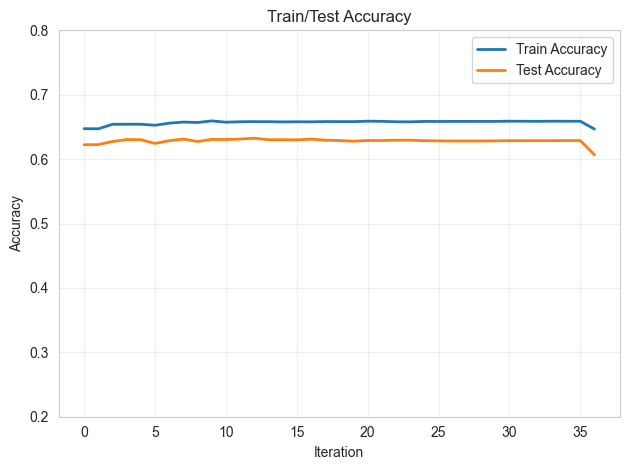

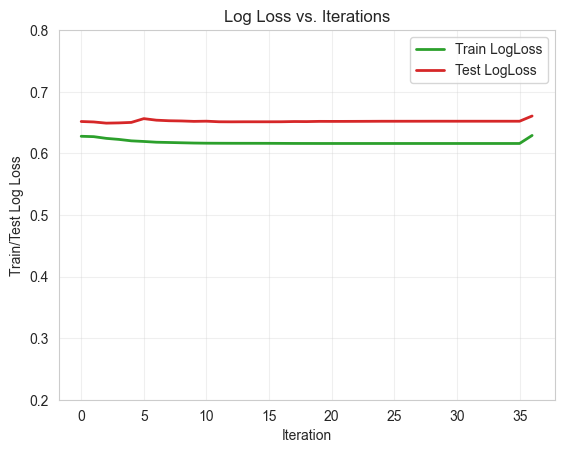

In [39]:
# --- Convert to numpy arrays for plotting ---
hist_baye_en_acc = result_baseline["history"]

# convert arrays safely
iters = np.asarray(pd.to_numeric(hist_baye_en_acc["iter"], errors="coerce"))
train_acc = np.array(hist_baye_en_acc["train_acc"], dtype=float)
test_acc  = np.array(hist_baye_en_acc["test_acc"], dtype=float)
train_ll  = np.array(hist_baye_en_acc["train_logloss"], dtype=float)
test_ll   = np.array(hist_baye_en_acc["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.2, 0.8)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.2, 0.8)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

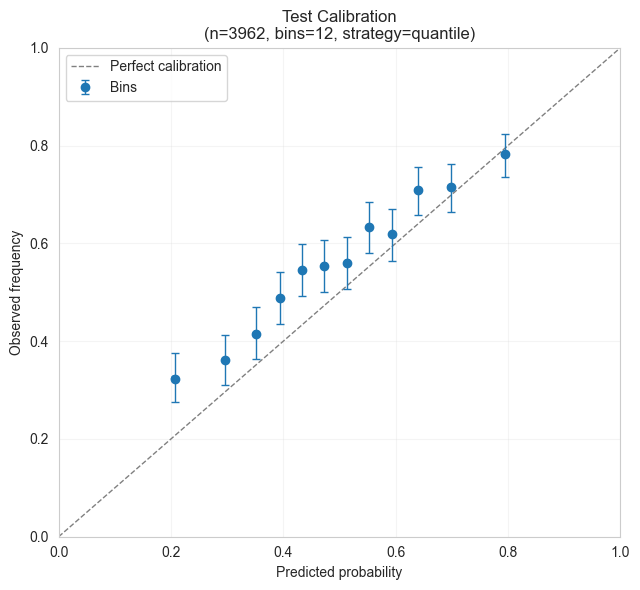

In [36]:
y_true_test = test['home_win'].astype(int).values
p_pred_test = best_model_acc.predict_proba(test)
calibration_curve_with_ci(y_true_test, p_pred_test, n_bins=12, strategy="quantile", title="Test Calibration")

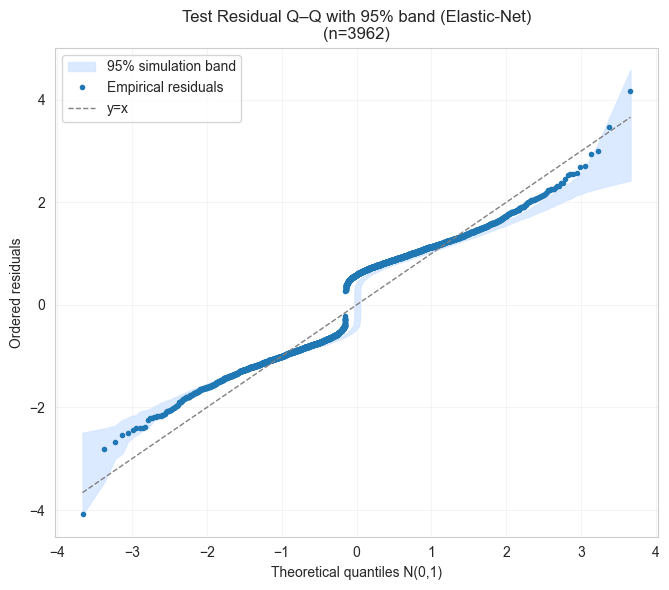

In [37]:
normal_probability_plot_with_band(y_true_test, p_pred_test, n_sim=800, title="Test Residual Q–Q with 95% band (Elastic-Net)")

(0.0, 50.0)

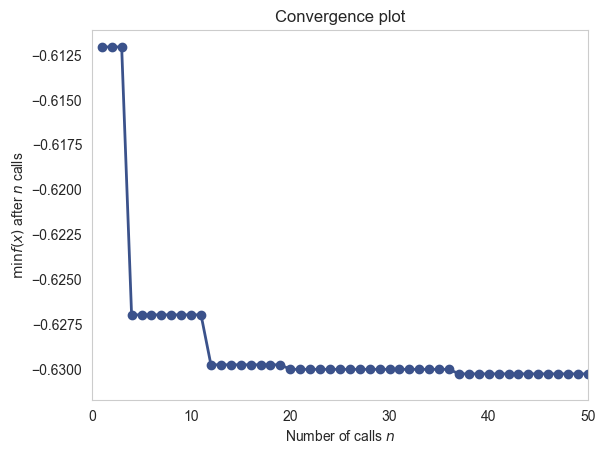

In [43]:
ax = plot_convergence(search_result)
ax.set_xlim(0, 50)

In [53]:
valid_df = df[df["split"] == "valid"]
Z_valid = np.zeros((len(valid_df), len(best_model_acc.context_cols)))
for j, col in enumerate(best_model_acc.context_cols):
    Z_valid[:, j] = (valid_df[col] - best_model_acc.mu_context[j]) / best_model_acc.sd_context[j]

# Decompose HCA into its components
valid_df["HCA_context"] = Z_valid @ best_model_acc.gamma
h_idx = valid_df["home_abbr"].map(best_model_acc.team_to_idx)
valid_df["HCA_total"] = valid_df["HCA_context"] + best_model_acc.alpha_hca[h_idx.values]
valid_df["theta_game"] = np.exp(valid_df["HCA_total"])

# Predicted probability of home team winning
valid_df["pred_prob_home_win"] = best_model_acc.predict_proba(valid_df)

# Classification label based on model threshold
valid_df["pred_label"] = (valid_df["pred_prob_home_win"] >= best_model_acc.threshold).astype(int)

# Extract ground truth and predictions
y_true = valid_df["home_win"].astype(int)
y_pred = valid_df["pred_label"].astype(int)

# Evaluation metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
logloss = log_loss(y_true, valid_df["pred_prob_home_win"])

print("Evaluation Metrics on VALIDATION Set")
print(f"Accuracy : {acc:.6f}")
print(f"Log Loss : {logloss:.6f}")
print(f"Precision: {prec:.6f}")
print(f"Recall   : {rec:.6f}")
print(f"F1 Score : {f1:.6f}")
valid_df.to_csv("results/en_validset.csv", index=False)

Evaluation Metrics on VALIDATION Set
Accuracy : 0.642586
Log Loss : 0.631075
Precision: 0.644186
Recall   : 0.771588
F1 Score : 0.702155


C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\158658855.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df["HCA_context"] = Z_valid @ best_model_acc.gamma
C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\158658855.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df["HCA_total"] = valid_df["HCA_context"] + best_model_acc.alpha_hca[h_idx.values]
C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\158658855.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

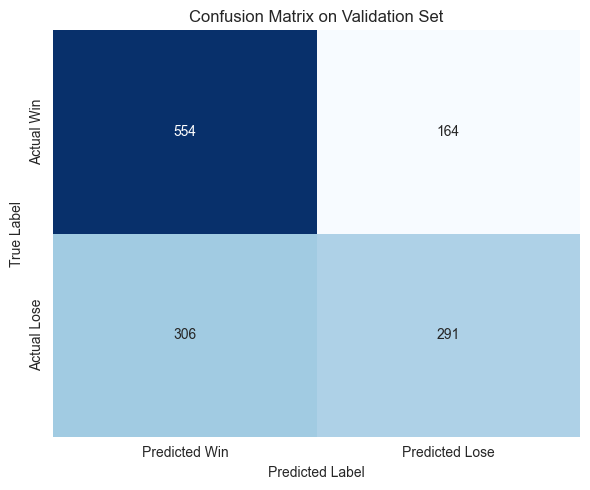

In [28]:
# Confusion matrix for home win vs home loss
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Predicted Win", "Predicted Lose"],
    yticklabels=["Actual Win", "Actual Lose"]
)
plt.title("Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

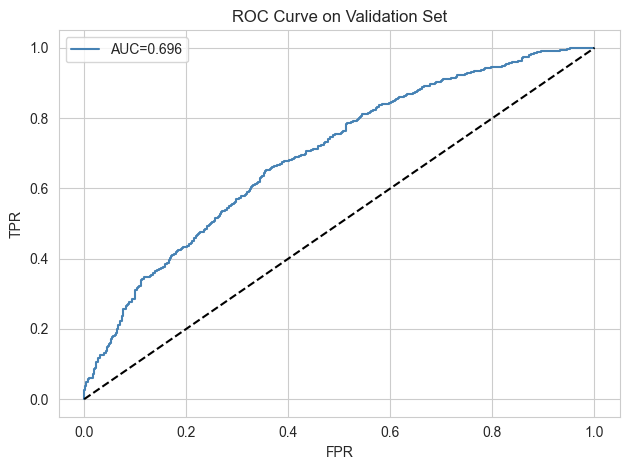

In [56]:
auc = roc_auc_score(y_true, valid_df["pred_prob_home_win"])
fpr, tpr, _ = roc_curve(y_true, valid_df["pred_prob_home_win"])
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}", color='steelblue')
plt.plot([0,1],[0,1],'k--')
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve on Validation Set")
plt.tight_layout(); plt.show()

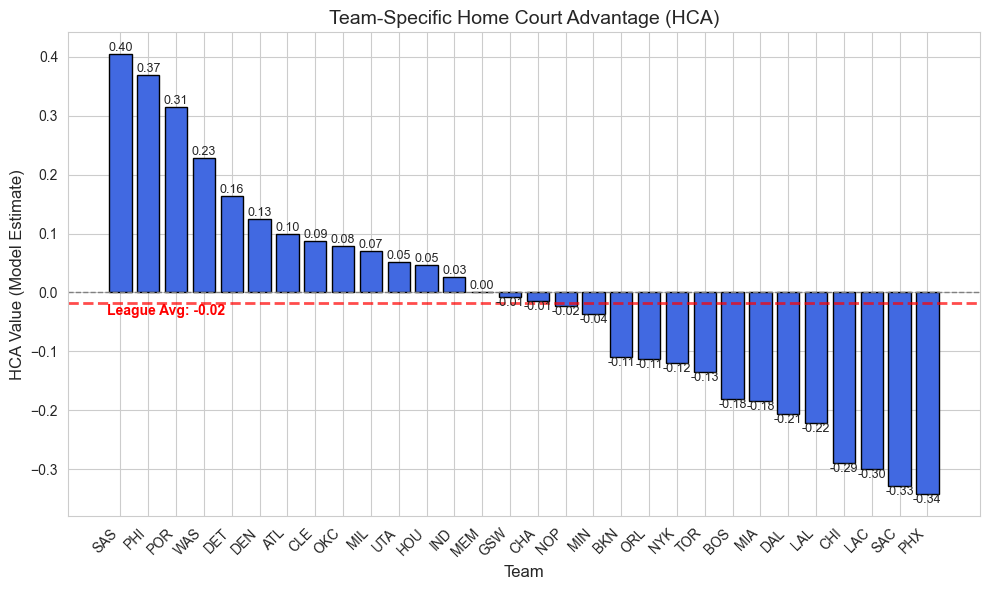

In [29]:
valid_results = pd.read_csv("./results/en_validset.csv")

team_total_hca = (
    valid_results.groupby("home_abbr")["HCA_total"]
    .mean()
    .sort_values(ascending=False)
)

hca_df = team_total_hca.reset_index().rename(
    columns={"home_abbr": "Team", "HCA_total": "HCA"}
)

# Compute league average HCA
league_avg_hca = hca_df["HCA"].mean()

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(hca_df["Team"], hca_df["HCA"], color="royalblue", edgecolor="black")

# Add horizontal lines
plt.axhline(0, color="gray", linewidth=1, linestyle="--")  # baseline zero
plt.axhline(y=league_avg_hca, color="red", linestyle="--", linewidth=2, alpha=0.7)  # league avg

# Annotate league average text
plt.text(-0.5, league_avg_hca + 0.02 if league_avg_hca >= 0 else league_avg_hca - 0.02,
         f"League Avg: {league_avg_hca:.2f}", color='red', fontsize=10, weight='bold')

# Labels and formatting
plt.title("Team-Specific Home Court Advantage (HCA)", fontsize=14)
plt.ylabel("HCA Value (Model Estimate)", fontsize=12)
plt.xlabel("Team", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Annotate each bar numerically
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.2f}", ha="center",
             va="bottom" if yval >= 0 else "top",
             fontsize=9)

plt.tight_layout()
plt.show()

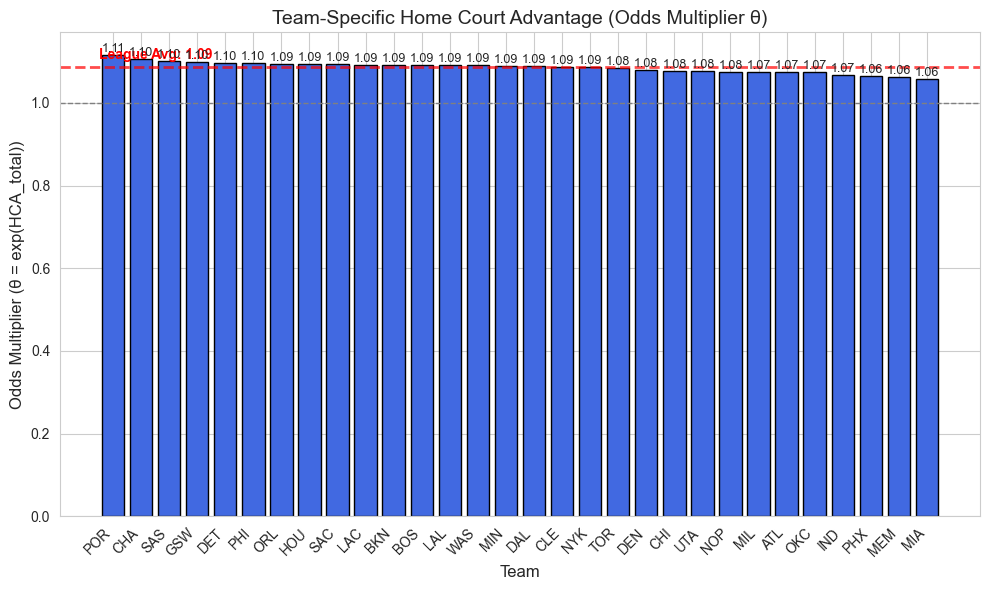

In [45]:
hca_df["Theta"] = np.exp(hca_df["HCA"])

plt.figure(figsize=(10, 6))
bars = plt.bar(hca_df["Team"], hca_df["Theta"], color="royalblue", edgecolor="black")

league_avg_theta = hca_df["Theta"].mean()

# Add horizontal lines
plt.axhline(1, color="gray", linewidth=1, linestyle="--")  # neutral odds multiplier = 1
plt.axhline(y=league_avg_theta, color="red", linestyle="--", linewidth=2, alpha=0.7)

# Annotate
plt.text(-0.5,
         league_avg_theta + 0.02 if league_avg_theta >= 1 else league_avg_theta - 0.02,
         f"League Avg: {league_avg_theta:.2f}",
         color='red', fontsize=10, weight='bold')

plt.title("Team-Specific Home Court Advantage (Odds Multiplier θ)", fontsize=14)
plt.ylabel("Odds Multiplier (θ = exp(HCA_total))", fontsize=12)
plt.xlabel("Team", fontsize=12)

plt.xticks(rotation=45, ha="right")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.2f}", ha="center",
             va="bottom" if yval >= 1 else "top",
             fontsize=9)
plt.tight_layout()
plt.show()

## L2 & ElasticNet Comparison

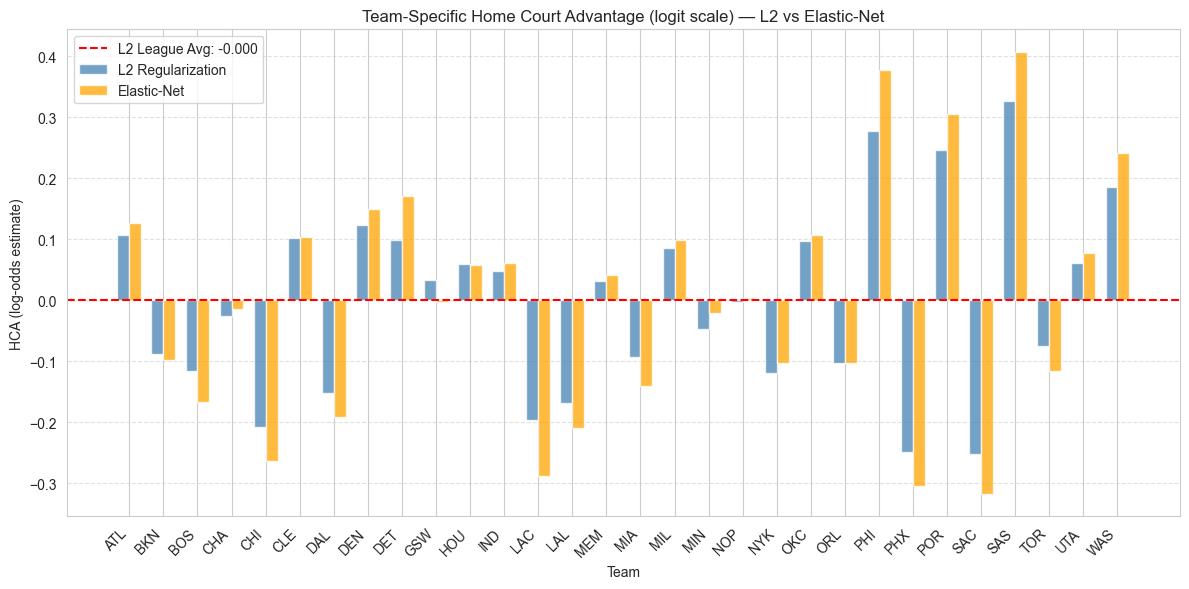

In [51]:
teams = model_l2.teams
alpha_l2   = model_l2.alpha_hca
alpha_enet = best_model_acc.alpha_hca[:len(alpha_l2)]
league_mean_l2   = np.mean(alpha_l2)
league_mean_enet = np.mean(alpha_enet)

plt.figure(figsize=(12,6))
width = 0.35
x = np.arange(len(teams))

plt.bar(x - width/2, alpha_l2, width, label='L2 Regularization', color='steelblue', alpha=0.75)
plt.bar(x + width/2, alpha_enet, width, label='Elastic-Net', color='orange', alpha=0.75)

plt.axhline(league_mean_l2, color='red', linestyle='--', linewidth=1.5,
            label=f"L2 League Avg: {league_mean_l2:.3f}")
plt.title("Team-Specific Home Court Advantage (logit scale) — L2 vs Elastic-Net")
plt.ylabel("HCA (log-odds estimate)")
plt.xlabel("Team")
plt.xticks(x, teams, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

C:\Users\hosiu\AppData\Local\Temp\ipykernel_38532\4130241993.py:20: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


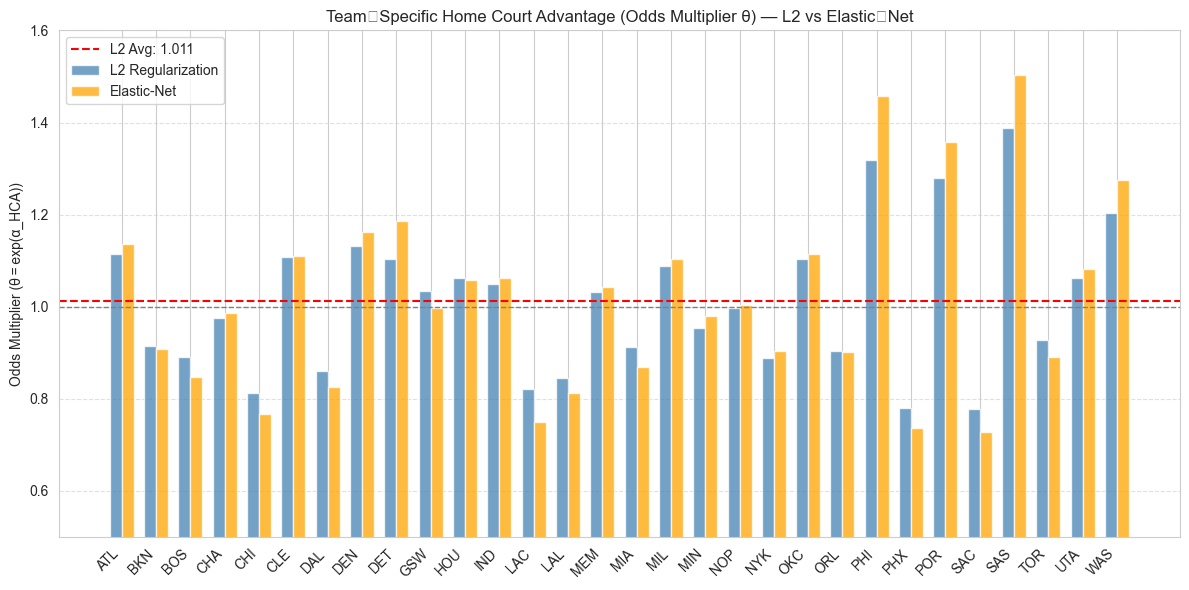

In [62]:
theta_l2   = np.exp(alpha_l2)
theta_enet = np.exp(alpha_enet)
league_mean_theta_l2   = np.mean(theta_l2)
league_mean_theta_enet = np.mean(theta_enet)

plt.figure(figsize=(12,6))
width = 0.35
x = np.arange(len(teams))

plt.bar(x - width/2, theta_l2, width, label='L2 Regularization', color='steelblue', alpha=0.75)
plt.bar(x + width/2, theta_enet, width, label='Elastic-Net', color='orange', alpha=0.75)
plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.axhline(league_mean_theta_l2, color='red', linestyle='--',
            linewidth=1.5, label=f"L2 Avg: {league_mean_theta_l2:.3f}")
plt.title("Team‑Specific Home Court Advantage (Odds Multiplier θ) — L2 vs Elastic‑Net")
plt.ylabel("Odds Multiplier (θ = exp(α_HCA))")
plt.xticks(x, teams, rotation=45, ha='right')
plt.ylim(0.5,1.6)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1619500935.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(prob_l2, label="L2", shade=True)
C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\1619500935.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(prob_en, label="Elastic‑Net", shade=True)


C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


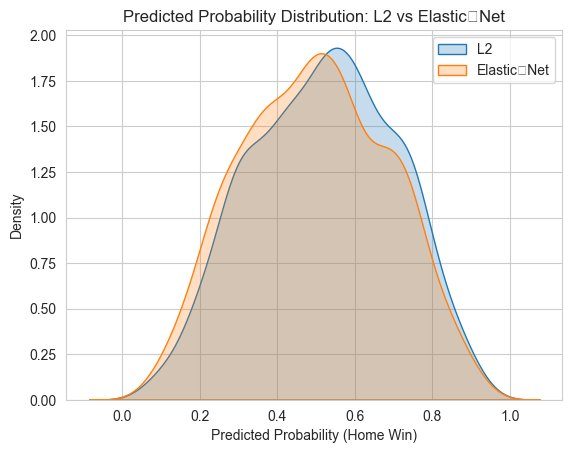

In [42]:
valid_df = df[df["split"]=="valid"]
l2_df = pd.read_csv("./results/valid_result.csv")
en_df = pd.read_csv("./results/en_validset.csv")
prob_l2=l2_df["pred_prob_home_win"]
prob_en=en_df["pred_prob_home_win"]

sns.kdeplot(prob_l2, label="L2", shade=True)
sns.kdeplot(prob_en, label="Elastic‑Net", shade=True)
plt.xlabel("Predicted Probability (Home Win)")
plt.title("Predicted Probability Distribution: L2 vs Elastic‑Net")
plt.legend()

### ROC / Precision–Recall curves

C:\Users\hosiu\AppData\Local\Temp\ipykernel_33840\127287910.py:21: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


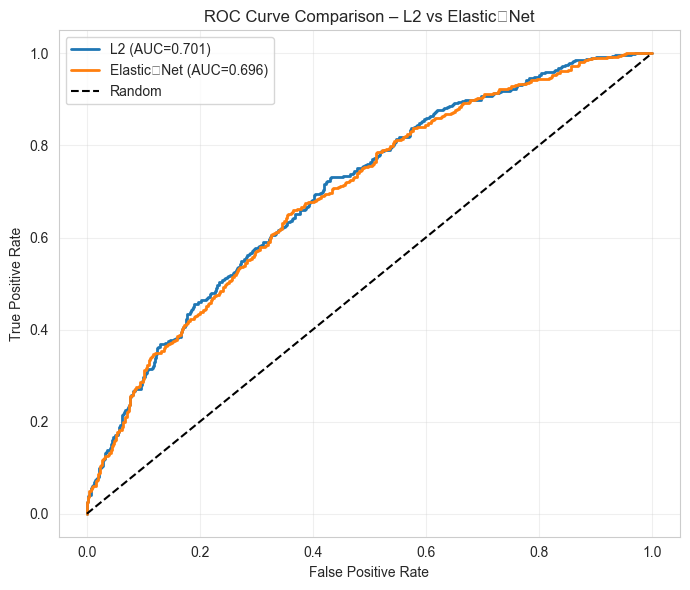

In [43]:
y_true = valid_df["home_win"]

# Compute ROC points
fpr_L2, tpr_L2, _ = roc_curve(y_true, prob_l2)
fpr_EN, tpr_EN, _ = roc_curve(y_true, prob_en)

# Compute scalar AUC values
auc_L2 = roc_auc_score(y_true, prob_l2)
auc_EN = roc_auc_score(y_true, prob_en)

# Plotting
plt.figure(figsize=(7, 6))
plt.plot(fpr_L2, tpr_L2, label=f"L2 (AUC={auc_L2:.3f})", linewidth=2)
plt.plot(fpr_EN, tpr_EN, label=f"Elastic‑Net (AUC={auc_EN:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – L2 vs Elastic‑Net")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Calibration curve comparison

Text(0.5, 1.0, 'Calibration Curves: L2 vs Elastic‑Net')

C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


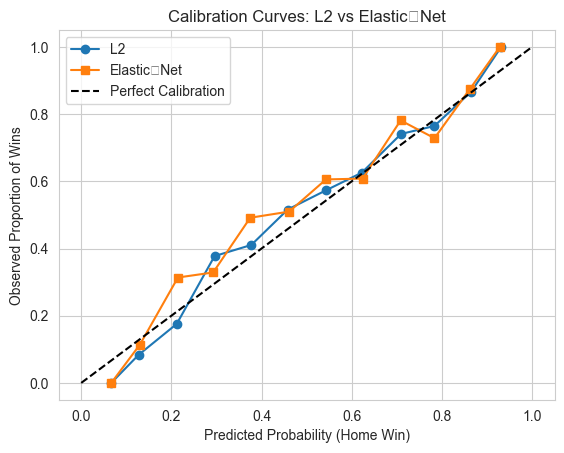

In [44]:
prob_true_L2, prob_pred_L2 = calibration_curve(y_true, prob_l2, n_bins=12)
prob_true_EN, prob_pred_EN = calibration_curve(y_true, prob_en, n_bins=12)
plt.plot(prob_pred_L2, prob_true_L2, "o-", label="L2")
plt.plot(prob_pred_EN, prob_true_EN, "s-", label="Elastic‑Net")
plt.plot([0,1],[0,1],"k--", label="Perfect Calibration")
plt.legend()
plt.xlabel("Predicted Probability (Home Win)")
plt.ylabel("Observed Proportion of Wins")
plt.title("Calibration Curves: L2 vs Elastic‑Net")

In [46]:
# Compare predicted probabilities
print(np.corrcoef(prob_l2, prob_en)[0,1],np.mean(np.abs(prob_l2 - prob_en)))

0.9794448209490969 0.03455258735372804


## Model Comparison (BT-model & BT-model wHCA)

## BT Model Without HCA

### 1. Map team abbreviations to numeric indices

In [326]:
df = pd.read_csv('./data/bt_games_cleaned.csv')

context_cols = ["home_b2b", "away_b2b","home_rest_days", "away_rest_days", "rest_diff"]
feature_cols = ["diff_recent_margin","diff_recent_win_pct","diff_pts_pg_to_date","split_win_pct_delta"]

df_train=df[df["split"]=="train"].copy()
df_test=df[df["split"]=="test"].copy()

In [327]:
all_teams = sorted(
    pd.unique(
        np.concatenate([df["home_abbr"].values, df["away_abbr"].values])
    )
)
team_to_idx = {t: i for i, t in enumerate(all_teams)}

In [330]:
num_teams = len(all_teams)

comparisons = []
for _, row in df_train.iterrows():
    home = team_to_idx[row["home_abbr"]]
    away = team_to_idx[row["away_abbr"]]
    if row["home_win"] == 1:
        comparisons.append((home, away))
    else:
        comparisons.append((away, home))

s_hat = choix.mm_pairwise(
    n_items=num_teams,
    data=comparisons,
    alpha=1e-5,
    tol=1e-5
)
s_hat -= np.mean(s_hat)

In [331]:
def predict_bt(df, s, team_to_idx):
    """Predict home‑win probabilities via σ(s_home − s_away)."""
    logits = np.array([
        s[team_to_idx[h]] - s[team_to_idx[a]]
        for h, a in zip(df.home_abbr, df.away_abbr)
    ])
    return 1 / (1 + np.exp(-logits))

In [332]:
# Train metrics
y_train = df_train.home_win.astype(int).values
p_train = predict_bt(df_train, s_hat, team_to_idx)

train_acc = accuracy_score(y_train, (p_train >= 0.5).astype(int))
train_ll  = log_loss(y_train, p_train)


# Test metrics
y_test = df_test.home_win.astype(int).values
p_test  = predict_bt(df_test, s_hat, team_to_idx)

test_acc = accuracy_score(y_test, (p_test >= 0.5).astype(int))
test_ll  = log_loss(y_test, p_test)


# Summary
print(f"Train accuracy: {train_acc:.6f} | Train log‑loss: {train_ll:.6f}")
print(f"Test  accuracy: {test_acc:.6f} | Test  log‑loss: {test_ll:.6f}")

Train accuracy: 0.597441 | Train log‑loss: 0.661021
Test  accuracy: 0.508146 | Test  log‑loss: 0.731237


## 3.2 BT With HCA

### Model Performance

In [336]:
def fit_bt_mm_hca(df, team_to_idx, max_iter=200, tol=1e-6):
    n = len(team_to_idx)

    home_idx = np.array([team_to_idx[t] for t in df.home_abbr])
    away_idx = np.array([team_to_idx[t] for t in df.away_abbr])
    y = df.home_win.astype(int).values

    # initialize
    w = np.ones(n)
    theta = 1.0

    for it in range(max_iter):
        w_old = w.copy()
        theta_old = theta

        denom_w = np.zeros(n)
        wins_w = np.zeros(n)

        # accumulate
        for h, a, yi in zip(home_idx, away_idx, y):
            denom = theta * w[h] + w[a]

            # contributions
            denom_w[h] += theta / denom
            denom_w[a] += 1.0 / denom

            # wins
            if yi == 1:
                wins_w[h] += 1
            else:
                wins_w[a] += 1

        # update w
        w = wins_w / (denom_w + 1e-12)

        # prevent zeros
        w = np.clip(w, 1e-12, None)

        # normalize
        w /= np.mean(w)

        # normalize (important for identifiability)
        w /= np.mean(w)

        # update theta
        num = np.sum(y)  # total home wins
        denom_theta = np.sum((w[home_idx]) / (theta * w[home_idx] + w[away_idx]))
        theta = num / (denom_theta + 1e-12)

        # convergence check
        if (
            np.max(np.abs(w - w_old)) < tol and
            abs(theta - theta_old) < tol
        ):
            break

    s = np.log(w)
    h = np.log(theta)

    return s, h

In [337]:
def predict_bt_hca(df, s, team_to_idx, h):
    home_idx = np.array([team_to_idx[t] for t in df.home_abbr])
    away_idx = np.array([team_to_idx[t] for t in df.away_abbr])

    z = s[home_idx] - s[away_idx] + h
    return 1 / (1 + np.exp(-z))

In [339]:
def evaluate_split(df, s, h, team_to_idx):
    y = df.home_win.astype(int).values
    p = predict_bt_hca(df, s, team_to_idx, h)

    acc = accuracy_score(y, (p >= 0.5))
    ll  = log_loss(y, p)

    return acc, ll

s_hat, h_hat = fit_bt_mm_hca(df_train, team_to_idx)

for name, df_split in [("Train", df_train), ("Test", df_test)]:
    acc, ll = evaluate_split(df_split, s_hat, h_hat, team_to_idx)
    print(f"{name:5s}  acc: {acc:.6f} | logloss: {ll:.6f}")

Train  acc: 0.621040 | logloss: 0.650022
Test   acc: 0.529708 | logloss: 0.725259
